
<center> <font size="5"> <div class="alert alert-block alert-success"> <strong> Millenium Business Process Conclusion Prediction </strong> </div> </font> </center>

|      |     Student Name     |     Student ID     |
|---   |         ---          |           ---          |
| 1    |     Matilde Santos    |       20201596         |
| 2    |      Francisco Castro      |       20230992         |
| 3    |      Joana Macedo        |       20201498         |
| 4    |      Inês Valverde       |       20201472         |

# 1. Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
import seaborn as sns
from math import ceil
import math
import warnings
from datetime import datetime
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer, KNNImputer
from difflib import SequenceMatcher
from mlxtend.frequent_patterns import apriori, association_rules
import re
import networkx as nx
import plotly.express as px
import scipy.sparse as sp
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, mean_squared_error, recall_score, precision_score, f1_score, accuracy_score
from collections import defaultdict
from sklearn.metrics import pairwise_distances
import random
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import make_scorer, f1_score, classification_report, confusion_matrix, roc_auc_score,  roc_curve, auc
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

In [ ]:

warnings.filterwarnings("ignore")

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# Global definitions
baseFolder = os.getcwd()
exportsFolder = baseFolder + os.sep +'Exports' + os.sep

subPlots_Title_fontSize = 12
subPlots_xAxis_fontSize = 10
subPlots_yAxis_fontSize = 10
subPlots_label_fontSize = 10
heatmaps_text_fontSize = 8

plots_Title_fontSize = 14
plots_Title_textColour = 'black'

plots_Legend_fontSize = 12
plots_Legend_textColour = 'black'

plots_barTexts_fontSize = 8

# 2. Datasets Loading

Task Execution Data: data regarding the execution of tasks, like start and finish dates, the activity, and the following tasks.
- **Request Identifier**: Identifier of the case. A case is composed by several activities.
- **Task arrival data**: Date the task arrives to Analysis and Resolve.
- **Task capture date**: Date when the task arrives to queue.
- **Task execution end date**: Date when the user finishes the task.
- **Task predicted end date**: The date when the task should be completed. When it is empty and the activity ID is 100, it means that the user doesn’t have a defined time to fill in the report. If the task is not done in time, the task is rejected.
- **ActivityID**: Identification number of the activity.
- **Task Executer**: Person that executed the task.
- **Task executer department**:
- **Task Type**: Type of the task.
- **Action**: Represents the task in the BPM diagram.
- **idBPMApplicationAction**: Identification number of the action.



In [ ]:
#Import Task Execution Data
task_execution_data = pd.read_excel('Case4_UNL-IMS - Data - delivery v2.xlsx', sheet_name='Q1 - Task execution data')

In [ ]:
task_execution_data.head()

,Task Id,Request Identifier,Task arrival date,Task capture date,Task execution end date,Task predicted end date,Actvity ID,Task Executer,Task executer department,Task Type,Action,idBPMApplicationAction
0,1584303,1,2022-04-11 16:02:13.820,2022-04-11 16:02:13.820,2022-04-11 16:02:13.820,NaN,100,7638.0,569.0,Initial Request,Submit initial request,270
1,1584304,1,2022-04-11 16:02:14.743,2022-04-12 09:29:40.683,2022-04-12 10:02:54.687,2022-04-12 14:02:14.803,102,4322.0,1104.0,Execution,NaN,273
2,1585980,1,2022-04-12 10:02:55.530,2022-04-12 10:14:39.290,2022-04-12 10:17:16.050,2022-04-12 17:02:55.577,103,10606.0,NaN,Execution,NaN,273
3,1586077,1,2022-04-12 10:17:16.427,2022-04-12 10:22:47.610,2022-05-10 13:43:32.203,2022-04-12 17:17:16.490,104,7638.0,569.0,Execution,Task executed with success,282
4,1671448,1,2022-05-10 13:43:32.627,2022-05-10 13:47:53.570,2022-05-10 13:48:44.353,2022-05-17 08:43:32.737,107,7638.0,569.0,Final task,Request accepted by requester,299


User Information Data: information about users, some personal information, and their roles in the company.
- **Task Executer**: Person that executed the task.
- **Sex**: Female, Male or Not Applicable. If Not Applicable may be considered robot machines.
- **BirthYear**: Year of birth of the user.
- **RoleID**: Role ID, which can be Director, Trainee, and others.
- **Is Manager**: Yes (S) if the user is a manager, otherwise No (N)
- **OrgUnitSince**: How many years has been working in that department? People with less experience (e.g. trainees) might be prone to do things that make the process.
- **IsOutSourcer**: Yes or No.


In [ ]:
user_info_data = pd.read_excel('Case4_UNL-IMS - Data - delivery v2.xlsx', sheet_name='Q2 - User information')

In [ ]:
user_info_data

,Task Executer,Sex,BirthYear,Role ID,Is Manager,OrgUnitSince,IsOutSourcer
0,1872,F,1988,1,Yes,2024,N
1,11133,F,1975,1,Yes,2019,N
2,10332,F,1978,2,Yes,2019,N
3,10349,F,1976,3,Yes,2024,N
4,1394,F,1984,4,Yes,2021,N
...,...,...,...,...,...,...,...
11365,3641,M,1968,21,No,2020,Y
11366,448,F,1974,5,Yes,2024,N
11367,9088,M,1971,5,Yes,2022,N
11368,2353,F,2000,22,Yes,2023,N


Specific Request Data:  information regarding the requests of each client.
- **idField**: Input on the start activity.
- **Request identifier**: Identifier of the case. A case is composed by several activities.
- **Value**: Value of the field identified with idField. We do not know the name of
the field for confidentiality reasons. In other words, this field will have a
value associated with the request with the corresponding id in Q1.


In [ ]:
#Import Specific Request Data
specific_request_data = pd.read_excel('Case4_UNL-IMS - Data - delivery v2.xlsx', sheet_name='Q3 - Specific request data')

In [ ]:
specific_request_data.head()

,idField,Request Identifier,Value
0,47,328,0
1,47,327,0
2,47,291,0
3,47,289,0
4,47,219,0


Rejections Data:  contains data about the tasks that were rejected.
- **Task Id**: ID of the task.
- **idBPMRequirement**: Identifier of the requirement.

In [ ]:
#Import Rejections Data
rejections_data = pd.read_excel('Case4_UNL-IMS - Data - delivery v2.xlsx', sheet_name='Q4 - Rejections')

In [ ]:
rejections_data.head()

,Task Id,idBPMRequirement
0,1606251,191
1,1606786,183
2,1629944,183
3,1643257,183
4,1643929,183


# 3. Datasets Exploration

## 3.1 Task Execution Data Exploration

In [ ]:
task_execution_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209017 entries, 0 to 209016
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Task Id                   209017 non-null  int64  
 1   Request Identifier        209017 non-null  int64  
 2   Task arrival date         209017 non-null  object 
 3   Task capture date         209017 non-null  object 
 4   Task execution end date   209017 non-null  object 
 5   Task predicted end date   163232 non-null  object 
 6   Actvity ID                209017 non-null  int64  
 7   Task Executer             188888 non-null  float64
 8   Task executer department  181887 non-null  float64
 9   Task Type                 209017 non-null  object 
 10  Action                    124576 non-null  object 
 11  idBPMApplicationAction    209017 non-null  int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 19.1+ MB


- Dates are type object, but should be datetime.
- *Task Executer* and *Task executer department* are always integer.
- Rename *Actvity ID* to *Activity ID*.


In [ ]:
task_execution_data.describe(include=['object']).T

,count,unique,top,freq
Task arrival date,209017,208936,2023-10-16 16:42:00.000,53
Task capture date,209017,202364,2023-12-06 10:58:00.000,4100
Task execution end date,209017,189229,2023-12-06 10:58:00.000,10598
Task predicted end date,163232,148867,2024-01-10 14:27:00.313,10
Task Type,209017,4,Execution,134815
Action,124576,6,Submit initial request,45775


- There are 9 different activities (matching with the BPM diagram).

In [ ]:
task_execution_data['Actvity ID'].unique()

array([100, 102, 103, 104, 107, 101, 105, 106, 108])

- There are 4 different type of tasks.

In [ ]:
task_execution_data['Task Type'].unique()

array(['Initial Request', 'Execution', 'Final task',
       'Requester response to rejection'], dtype=object)

- The number of actions is inferior to the number of idBPMApplicationAction, which means that some of the missing values are assumed to be information that cannot be discloured due to privacy questions.

In [ ]:
task_execution_data['Action'].unique()

array(['Submit initial request', nan, 'Task executed with success',
       'Request accepted by requester', 'Task returned to team',
       'Task automaticaly terminated - SLA time reached',
       'Task terminated - administrative closure'], dtype=object)

In [ ]:
task_execution_data['idBPMApplicationAction'].unique()

array([ 270,  273,  282,  299,  298,  290,  271, 2981, 8888,  888,  278,
        272,  300,  301,  274,  279,  275,  777, 2982])

### 3.1.1 Missing Values

In [ ]:
#Check missing values
round(task_execution_data.isna().sum()/len(task_execution_data),4)*100

Task Id                      0.00
Request Identifier           0.00
Task arrival date            0.00
Task capture date            0.00
Task execution end date      0.00
Task predicted end date     21.90
Actvity ID                   0.00
Task Executer                9.63
Task executer department    12.98
Task Type                    0.00
Action                      40.40
idBPMApplicationAction       0.00
dtype: float64

We have to evaluate the missing values in more detail, because there might be a meaning for some of them.

For the **missing values in the Action** column, it represents an action for which we cannot have a description for privacy reasons.

For the **missing values in Task Executer and Task executer department**, we have identified 3 possible cases:

1. Activities without executer, but with a value in department. We assumed that these users left the company, applying the code 12 000 to both executer and department.

In [ ]:
task_execution_data[(task_execution_data['Task Executer'].isna()) & (~task_execution_data['Task executer department'].isna())]

,Task Id,Request Identifier,Task arrival date,Task capture date,Task execution end date,Task predicted end date,Actvity ID,Task Executer,Task executer department,Task Type,Action,idBPMApplicationAction
56,1625962,13,2022-04-28 12:02:50.183,2022-05-05 15:16:32.910,2022-05-05 15:19:12.330,2022-04-18 10:24:41.830,102,NaN,1104.0,Execution,Task returned to team,290
91,1603523,20,2022-04-19 18:32:14.033,2022-04-20 11:13:51.013,2022-04-20 12:20:45.787,2022-04-20 15:30:00.180,102,NaN,1104.0,Execution,NaN,273
104,1612242,23,2022-04-22 10:03:10.163,2022-04-22 10:05:29.270,2022-04-22 16:08:00.453,2022-04-22 17:03:10.220,102,NaN,1104.0,Execution,NaN,273
264,1648665,56,2022-05-05 14:53:22.673,2022-05-05 15:34:14.560,2022-05-05 15:37:46.590,2022-05-06 12:53:23.913,102,NaN,1104.0,Execution,Task returned to team,290
280,1670909,59,2022-05-10 12:12:18.980,2022-05-11 11:15:47.880,2022-05-11 12:36:35.253,2022-05-05 10:38:47.957,102,NaN,1104.0,Execution,NaN,273
...,...,...,...,...,...,...,...,...,...,...,...,...
201208,6152409,44267,2024-02-22 11:27:20.843,2024-02-22 11:38:53.580,2024-02-22 11:48:18.463,2024-02-23 09:27:20.920,102,NaN,1146.0,Execution,NaN,275
202617,6289024,44528,2024-02-28 16:00:07.363,2024-02-28 16:00:07.363,2024-02-28 16:00:07.363,NaN,100,NaN,191.0,Initial Request,Submit initial request,270
202619,6351920,44528,2024-03-01 15:40:05.690,2024-03-01 15:53:22.137,2024-03-08 10:40:06.027,2024-03-08 10:40:05.737,107,NaN,191.0,Final task,Task automaticaly terminated - SLA time reached,888
208962,6626510,45763,2024-04-01 09:00:39.393,2024-04-01 09:00:39.393,2024-04-01 09:00:39.393,NaN,100,NaN,529.0,Initial Request,Submit initial request,270


In [ ]:
# Percentage of cases that have activities without executer but the empty executer has a department
(len(task_execution_data[(task_execution_data['Task Executer'].isna()) & (~task_execution_data['Task executer department'].isna())]['Request Identifier'].unique())/len(task_execution_data['Request Identifier'].unique()))*100

11.046054356375077

In [ ]:
# Replace missing values in 'Task Executer' and 'Task executer department' columns with 12000
task_execution_data.loc[(task_execution_data['Task Executer'].isna()) & (~task_execution_data['Task executer department'].isna()), 'Task Executer'] = 12000

In [ ]:
task_execution_data.loc[(task_execution_data['Task Executer'] == 12000), 'Task executer department'] = 12000

2. Activities without department but with a value in executer. These cases can take 3 types:
- Activities that never had a department, always NaN.
- Activities that have a department, so only one unique value in department besides NaN.
- Activities that have changed department, so they have more than one unique value for the department.

In [ ]:
task_execution_data[(~task_execution_data['Task Executer'].isna()) & (task_execution_data['Task executer department'].isna())]

,Task Id,Request Identifier,Task arrival date,Task capture date,Task execution end date,Task predicted end date,Actvity ID,Task Executer,Task executer department,Task Type,Action,idBPMApplicationAction
2,1585980,1,2022-04-12 10:02:55.530,2022-04-12 10:14:39.290,2022-04-12 10:17:16.050,2022-04-12 17:02:55.577,103,10606.0,NaN,Execution,NaN,273
7,1587111,2,2022-04-12 12:35:56.890,2022-04-12 13:44:25.607,2022-04-12 13:45:24.067,2022-04-13 10:35:56.930,103,10606.0,NaN,Execution,NaN,273
19,1669180,5,2022-05-10 08:50:28.543,2022-05-10 08:50:49.607,2022-05-11 09:27:02.043,2022-05-10 15:50:28.753,103,73.0,NaN,Execution,NaN,273
24,1626130,6,2022-04-28 12:24:55.870,2022-04-28 13:24:00.790,2022-04-28 13:29:37.443,2022-04-29 10:24:55.923,103,10925.0,NaN,Execution,NaN,273
29,1739770,7,2022-05-22 21:23:42.667,2022-05-22 21:47:44.610,2022-05-22 21:49:44.713,2022-05-23 15:30:00.287,103,10606.0,NaN,Execution,NaN,273
...,...,...,...,...,...,...,...,...,...,...,...,...
150897,4078743,34162,2023-08-19 18:51:21.417,2023-08-21 08:35:58.030,2023-08-21 10:33:57.350,2023-08-21 15:30:00.483,104,8314.0,NaN,Execution,Task executed with success,282
150898,4080750,34162,2023-08-21 10:33:57.740,2023-08-21 11:35:19.050,2023-08-25 14:34:00.940,2023-08-25 14:33:57.847,107,8314.0,NaN,Final task,Task automaticaly terminated - SLA time reached,888
186731,5019641,41639,2024-01-03 12:51:48.113,2024-01-09 09:09:08.230,2024-01-09 09:10:10.383,2024-01-04 10:37:04.570,104,686.0,NaN,Execution,Task returned to team,290
203732,6397471,44750,2024-03-05 09:34:11.507,2024-03-05 09:34:11.507,2024-03-05 09:34:11.507,NaN,100,8979.0,NaN,Initial Request,Submit initial request,270


- Users that never had a department, always NaN.

These can be outsourcers, but after checking this is not the case of these executers. These are going to be assumed as errors, and the cases where these executers appear are going to be eliminated from the dataset.

In [ ]:
# Filter rows where 'Task Executer' is not null but 'Task executer department' is null
filtered_rows = task_execution_data[(~task_execution_data['Task Executer'].isna()) & (task_execution_data['Task executer department'].isna())]

# Find unique executors from the filtered rows
unique_executors = filtered_rows['Task Executer'].unique()

# Initialize a list to store executors who never had a value in the department field
executors_without_department = []

# Iterate over unique executors and check if any of them have a department value in other rows
for executor in unique_executors:
    if task_execution_data[(task_execution_data['Task Executer'] == executor) & (~task_execution_data['Task executer department'].isna())].empty:
        executors_without_department.append(executor)

print("Executors who never had a value in the department field:")
print(executors_without_department)

Executors who never had a value in the department field:
[10480.0, 9963.0, 10564.0, 10732.0, 80.0, 9023.0, 11048.0, 7768.0, 1524.0, 8314.0]


In [ ]:
# All the users in this case are not outsourcers
for user in executors_without_department:
  print(user_info_data[(user_info_data['Task Executer'] == user)])

      Task Executer Sex  BirthYear  Role ID Is Manager  OrgUnitSince  \
1993          10480   M       1969        6        Yes          2024   

     IsOutSourcer  
1993            N  
      Task Executer Sex  BirthYear  Role ID Is Manager  OrgUnitSince  \
6372           9963   F       1972       29        Yes          2023   

     IsOutSourcer  
6372            N  
       Task Executer Sex  BirthYear  Role ID Is Manager  OrgUnitSince  \
11150          10564   F       1973       10        Yes          2022   

      IsOutSourcer  
11150            N  
      Task Executer Sex  BirthYear  Role ID Is Manager  OrgUnitSince  \
1213          10732   M       1975       13        Yes          2023   

     IsOutSourcer  
1213            N  
      Task Executer Sex  BirthYear  Role ID Is Manager  OrgUnitSince  \
4244             80   F       1973        3        Yes          2023   

     IsOutSourcer  
4244            N  
      Task Executer Sex  BirthYear  Role ID Is Manager  OrgUnitSince  \

In [ ]:
#Check the requests with executors that never had a department
unique_requests_executors_without_department = task_execution_data[task_execution_data['Task Executer'].isin(executors_without_department)]['Request Identifier'].unique()

In [ ]:
(len(task_execution_data[task_execution_data['Request Identifier'].isin(unique_requests_executors_without_department)])/len(task_execution_data['Request Identifier'].unique()))*100

1.5817530367910515

In [ ]:
task_execution_data.drop(task_execution_data[task_execution_data['Request Identifier'].isin(unique_requests_executors_without_department)].index, inplace=True)

- Users that have a department, so only one unique value in department besides NaN.

The missing values in department in these cases are going to be replaced by the only value they have.

In [ ]:
# Filter rows where 'Task Executer' is not null but 'Task executer department' is null
filtered_rows = task_execution_data[(~task_execution_data['Task Executer'].isna()) & (task_execution_data['Task executer department'].isna())]

# Find unique executors from the filtered rows
unique_executors = filtered_rows['Task Executer'].unique()

# Initialize a list to store executors who never had a value in the department field
executors_with_one_department = []

# Iterate over unique executors and check if any of them have more than one department value
for executor in unique_executors:
    if len(task_execution_data[task_execution_data['Task Executer'] == executor]['Task executer department'].unique()) == 2:
        executors_with_one_department.append(executor)

print("Executors who have one unique department:")
print(executors_with_one_department)

Executors who have one unique department:
[73.0, 10925.0, 10383.0, 10654.0, 7945.0, 425.0, 10588.0, 10941.0, 7854.0, 8609.0, 10328.0, 1052.0, 686.0]


In [ ]:
# Iterate over executors with one department value
for executor in executors_with_one_department:
    # Get the unique department value for this executor
    unique_department = task_execution_data[task_execution_data['Task Executer'] == executor]['Task executer department'].dropna().unique()[0]
    # Replace missing values with the unique department value for this executor
    task_execution_data.loc[task_execution_data['Task Executer'] == executor, 'Task executer department'] = task_execution_data.loc[task_execution_data['Task Executer'] == executor, 'Task executer department'].fillna(unique_department)

- Users that have changed department, so they have more than one unique value for the department.

The missing values in department are going to be replaced by the value more close to the NaN.

In [ ]:
# Filter rows where 'Task Executer' is not null but 'Task executer department' is null
filtered_rows = task_execution_data[(~task_execution_data['Task Executer'].isna()) & (task_execution_data['Task executer department'].isna())]

# Find unique executors from the filtered rows
unique_executors = filtered_rows['Task Executer'].unique()

# Initialize a list to store executors who never had a value in the department field
executors_with_several_departments = []

# Iterate over unique executors and check if any of them have more than one department value
for executor in unique_executors:
    if len(task_execution_data[task_execution_data['Task Executer'] == executor]['Task executer department'].unique()) > 2:
        executors_with_several_departments.append(executor)

print("Executors who have more than one unique department field:")
print(executors_with_several_departments)

Executors who have more than one unique department field:
[10606.0, 9078.0, 8979.0]


In [ ]:
# Define a function to fill missing department values for a specific executor
def fill_missing_department(executor_id):
    # Filter rows for the executor
    executor_data = task_execution_data[task_execution_data['Task Executer'] == executor_id]
    # Sort by 'Task arrival date'
    executor_data = executor_data.sort_values(by='Task arrival date')
    # Forward-fill missing department values
    executor_data['Task executer department'] = executor_data['Task executer department'].fillna(method='ffill')
    # Backward-fill any remaining missing values
    executor_data['Task executer department'] = executor_data['Task executer department'].fillna(method='bfill')
    # Update task_execution_data with the filled values
    task_execution_data.update(executor_data)

In [ ]:
# Fill missing department values for each executor
for executor in executors_with_several_departments:
    fill_missing_department(executor)

3. Users without any value in executer and department: These are assumed to be employees that are no longer in the company, so they don't have an executer and department number. A new code (12 000) will be created to represent these cases.

In [ ]:
task_execution_data[task_execution_data['Task Executer'].isna() & task_execution_data['Task executer department'].isna()]

,Task Id,Request Identifier,Task arrival date,Task capture date,Task execution end date,Task predicted end date,Actvity ID,Task Executer,Task executer department,Task Type,Action,idBPMApplicationAction
15,1609274,4,2022-04-21 11:54:32.263,2022-04-26 09:54:32.757,2022-04-26 09:54:32.757,2022-04-26 09:54:32.317,101,NaN,NaN,Requester response to rejection,Task automaticaly terminated - SLA time reached,2981
53,1602749,12,2022-04-19 16:02:08.233,2022-04-27 11:02:08.633,2022-04-27 11:02:08.633,2022-04-27 11:02:08.297,107,NaN,NaN,Final task,Task automaticaly terminated - SLA time reached,888
60,1836814,13,2022-06-14 11:04:09.720,2022-06-21 15:04:13.713,2022-06-21 15:04:13.713,2022-06-21 15:04:09.877,107,NaN,NaN,Final task,Task automaticaly terminated - SLA time reached,888
79,1803881,17,2022-06-07 08:15:06.323,2022-06-14 12:30:02.690,2022-06-14 12:30:02.690,2022-06-14 12:30:00.073,107,NaN,NaN,Final task,Task automaticaly terminated - SLA time reached,888
89,1654150,19,2022-05-06 17:46:08.280,2022-05-13 12:30:03.583,2022-05-13 12:30:03.583,2022-05-13 12:30:00.353,107,NaN,NaN,Final task,Task automaticaly terminated - SLA time reached,888
...,...,...,...,...,...,...,...,...,...,...,...,...
208945,6678372,45759,2024-04-08 10:57:47.697,2024-04-12 14:57:50.073,2024-04-12 14:57:50.073,2024-04-12 14:57:47.730,107,NaN,NaN,Final task,Task automaticaly terminated - SLA time reached,888
208965,6631993,45763,2024-04-01 14:45:33.573,2024-04-08 09:45:34.080,2024-04-08 09:45:34.080,2024-04-08 09:45:33.737,107,NaN,NaN,Final task,Task automaticaly terminated - SLA time reached,888
208989,6634616,45767,2024-04-01 17:15:29.120,2024-04-08 12:15:29.427,2024-04-08 12:15:29.430,2024-04-08 12:15:29.170,107,NaN,NaN,Final task,Task automaticaly terminated - SLA time reached,888
208995,6692068,45768,2024-04-09 15:32:39.317,2024-04-16 10:32:40.020,2024-04-16 10:32:40.020,2024-04-16 10:32:39.390,107,NaN,NaN,Final task,Task automaticaly terminated - SLA time reached,888


In [ ]:
# Replace missing values in 'Task Executer' and 'Task executer department' columns with 12000
task_execution_data.loc[task_execution_data['Task Executer'].isna() & task_execution_data['Task executer department'].isna(), 'Task Executer'] = 12000

In [ ]:
task_execution_data.loc[(task_execution_data['Task Executer'] == 12000), 'Task executer department'] = 12000

For the **missing values in task predicted end date**, we have identified two cases:

1. When the predicted end date is missing, and activity ID is not 100:

We assumed that this cannot happen. These requests were eliminated from the dataset.

In [ ]:
task_execution_data[(task_execution_data['Task predicted end date'].isna()) & (task_execution_data['Actvity ID'] != 100)]

,Task Id,Request Identifier,Task arrival date,Task capture date,Task execution end date,Task predicted end date,Actvity ID,Task Executer,Task executer department,Task Type,Action,idBPMApplicationAction
14245,2520574,3174,2022-12-16 11:44:57.053,2022-12-16 11:44:57.053,2022-12-16 11:44:57.053,NaN,107,12000.0,12000.0,Final task,Task automaticaly terminated - SLA time reached,888
30148,2531427,6759,2022-12-20 10:08:10.280,2022-12-20 10:08:10.280,2022-12-20 10:42:57.480,NaN,104,309.0,596.0,Execution,Task returned to team,290
30149,2531752,6759,2022-12-20 10:42:59.353,2023-01-12 18:28:28.190,2023-01-12 18:35:09.753,NaN,104,309.0,596.0,Execution,Task executed with success,282
31872,2520582,7146,2022-12-16 11:45:32.260,2022-12-16 11:45:32.260,2022-12-16 11:45:32.260,NaN,107,12000.0,12000.0,Final task,Task automaticaly terminated - SLA time reached,888
42437,2520751,9494,2022-12-16 12:06:01.000,2022-12-16 12:06:01.000,2022-12-16 12:06:01.000,NaN,107,12000.0,12000.0,Final task,Task automaticaly terminated - SLA time reached,888
44414,2520757,9935,2022-12-16 12:06:31.970,2022-12-16 12:06:31.970,2022-12-16 12:06:31.970,NaN,107,12000.0,12000.0,Final task,Task automaticaly terminated - SLA time reached,888
48523,2520804,10854,2022-12-16 12:12:14.107,2022-12-16 12:12:14.107,2022-12-16 12:12:14.107,NaN,107,12000.0,12000.0,Final task,Task automaticaly terminated - SLA time reached,888
49201,2520820,11003,2022-12-16 12:13:52.100,2022-12-16 12:13:52.100,2022-12-16 12:13:52.100,NaN,107,12000.0,12000.0,Final task,Task automaticaly terminated - SLA time reached,888
53272,2520868,11888,2022-12-16 12:22:55.813,2022-12-16 12:22:55.813,2022-12-16 12:22:55.813,NaN,107,12000.0,12000.0,Final task,Task automaticaly terminated - SLA time reached,888
58022,2520870,12922,2022-12-16 12:23:37.787,2022-12-16 12:23:37.787,2022-12-16 12:23:37.787,NaN,107,12000.0,12000.0,Final task,Task automaticaly terminated - SLA time reached,888


In [ ]:
#Check the requests where the predicted end data is empty and Activity ID is different than 100
requests_activity_diff100 = task_execution_data[task_execution_data['Request Identifier'].isin(task_execution_data[(task_execution_data['Task predicted end date'].isna()) & (task_execution_data['Actvity ID'] != 100)]['Request Identifier'].unique())]
requests_activity_diff100

,Task Id,Request Identifier,Task arrival date,Task capture date,Task execution end date,Task predicted end date,Actvity ID,Task Executer,Task executer department,Task Type,Action,idBPMApplicationAction
14241,1905201,3174,2022-06-29 15:39:13.310,2022-06-29 15:39:13.310,2022-06-29 15:39:13.310,NaN,100,9650.0,557.0,Initial Request,Submit initial request,270
14242,1905202,3174,2022-06-29 15:39:15.263,2022-07-01 13:59:16.147,2022-07-01 14:28:03.457,2022-06-30 13:39:15.540,102,12000.0,12000.0,Execution,NaN,273
14243,1914902,3174,2022-07-01 14:28:04.673,2022-07-01 14:35:17.613,2022-07-01 14:36:51.700,2022-07-04 12:28:04.747,103,10606.0,1147.0,Execution,NaN,273
14244,1914973,3174,2022-07-01 14:36:53.247,2022-07-01 14:42:36.057,2022-07-01 14:50:46.500,2022-07-04 12:36:53.897,104,9650.0,557.0,Execution,Task executed with success,282
14245,2520574,3174,2022-12-16 11:44:57.053,2022-12-16 11:44:57.053,2022-12-16 11:44:57.053,NaN,107,12000.0,12000.0,Final task,Task automaticaly terminated - SLA time reached,888
...,...,...,...,...,...,...,...,...,...,...,...,...
78985,2686297,17498,2023-01-19 08:58:02.587,2023-01-19 08:58:02.587,2023-12-06 10:58:00.000,NaN,104,10493.0,174.0,Execution,Task terminated - administrative closure,8888
82989,2728516,18381,2023-01-30 09:17:40.493,2023-01-30 09:17:40.493,2023-01-30 09:17:40.493,NaN,100,8673.0,719.0,Initial Request,Submit initial request,270
82990,2728518,18381,2023-01-30 09:17:44.777,2023-01-30 09:18:46.280,2023-01-30 09:25:29.190,2023-01-30 16:17:44.963,102,4322.0,1104.0,Execution,NaN,275
82991,2728592,18381,2023-01-30 09:25:30.130,2023-01-30 09:55:14.650,2023-04-24 16:31:17.987,2023-01-30 16:25:30.167,104,8673.0,719.0,Execution,Task returned to team,290


In [ ]:
# Drop the observations where the predicted end data is empty and Activity ID is different than 100
task_execution_data.drop(requests_activity_diff100.index, inplace=True)

2. When it is empty and the activity ID is 100, it means that the user doesn’t have a defined time to fill in the report.

These missing values are replaced by the same value as Task Execution Date.

In [ ]:
# Replace NAN by the Task Execution End Data
task_execution_data[(task_execution_data['Task predicted end date'].isna()) & (task_execution_data['Actvity ID'] == 100)]

,Task Id,Request Identifier,Task arrival date,Task capture date,Task execution end date,Task predicted end date,Actvity ID,Task Executer,Task executer department,Task Type,Action,idBPMApplicationAction
0,1584303,1,2022-04-11 16:02:13.820,2022-04-11 16:02:13.820,2022-04-11 16:02:13.820,NaN,100,7638.0,569.0,Initial Request,Submit initial request,270
5,1586253,2,2022-04-12 10:50:25.570,2022-04-12 10:50:25.570,2022-04-12 10:50:25.570,NaN,100,598.0,606.0,Initial Request,Submit initial request,270
10,1589361,3,2022-04-12 18:09:29.153,2022-04-12 18:09:29.153,2022-04-12 18:09:29.153,NaN,100,11029.0,167.0,Initial Request,Submit initial request,270
12,1589605,4,2022-04-13 08:15:39.620,2022-04-13 08:15:39.620,2022-04-13 08:15:39.620,NaN,100,924.0,569.0,Initial Request,Submit initial request,270
16,1589669,5,2022-04-13 08:37:34.943,2022-04-13 08:37:34.943,2022-04-13 08:37:34.943,NaN,100,8601.0,167.0,Initial Request,Submit initial request,270
...,...,...,...,...,...,...,...,...,...,...,...,...
208990,6626572,45768,2024-04-01 09:08:13.167,2024-04-01 09:08:13.167,2024-04-01 09:08:13.167,NaN,100,610.0,453.0,Initial Request,Submit initial request,270
208996,6626639,45769,2024-04-01 09:13:34.370,2024-04-01 09:13:34.370,2024-04-01 09:13:34.370,NaN,100,9549.0,347.0,Initial Request,Submit initial request,270
209002,6627063,45770,2024-04-01 09:45:06.497,2024-04-01 09:45:06.497,2024-04-01 09:45:06.497,NaN,100,7351.0,585.0,Initial Request,Submit initial request,270
209007,6728664,45771,2024-04-15 18:16:21.270,2024-04-15 18:16:21.270,2024-04-15 18:16:21.270,NaN,100,7945.0,478.0,Initial Request,Submit initial request,270


In [ ]:
# Filter rows where 'Task predicted end date' is NaN and 'Activity ID' is 100
missing_predicted_end_date_rows = task_execution_data[
    (task_execution_data['Task predicted end date'].isna()) &
    (task_execution_data['Actvity ID'] == 100)
]

# Replace missing values in 'Task predicted end date' with corresponding values from 'Task execution end date'
task_execution_data.loc[missing_predicted_end_date_rows.index, 'Task predicted end date'] = \
    missing_predicted_end_date_rows['Task execution end date']

In [ ]:
# Confirm that the missing values are treated
round(task_execution_data.isna().sum()/len(task_execution_data),4)*100

Task Id                      0.00
Request Identifier           0.00
Task arrival date            0.00
Task capture date            0.00
Task execution end date      0.00
Task predicted end date      0.00
Actvity ID                   0.00
Task Executer                0.00
Task executer department     0.00
Task Type                    0.00
Action                      40.38
idBPMApplicationAction       0.00
dtype: float64

### 3.1.2 Duplicates

In [ ]:
# Check duplicates
task_execution_data.duplicated(subset=task_execution_data.columns.difference(['Task Id'])).sum()

0

## 3.2 User Information Data Exploration

In [ ]:
user_info_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11370 entries, 0 to 11369
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Task Executer  11370 non-null  int64 
 1   Sex            11370 non-null  object
 2   BirthYear      11370 non-null  int64 
 3   Role ID        11370 non-null  int64 
 4   Is Manager     11370 non-null  object
 5   OrgUnitSince   11370 non-null  int64 
 6   IsOutSourcer   11370 non-null  object
dtypes: int64(4), object(3)
memory usage: 621.9+ KB


- *Sex*, *Is Manager* and *IsOutSourcer* can be converted to binary columns, because the values can only take two values "Yes" or "No".
- Rename *Sex* to *Gender*.
- *BirthYear* and *OrgUnitSince* are going to be used to calculate the user age and seniority in the department, respectively.

In [ ]:
user_info_data.describe(include=['object']).T

,count,unique,top,freq
Sex,11370,4,M,6048
Is Manager,11370,2,Yes,7290
IsOutSourcer,11370,2,N,7290


- *Sex* should only have 3 unique values: 'F', 'M', and 'U'.

In [ ]:
user_info_data['Sex'].value_counts()

Sex
M    6048
F    4763
      442
U     117
Name: count, dtype: int64

- There are empty values and undefined (U) values in gender. According to Millenium, undefined values (U) and empty values may be considered robots machines.


In [ ]:
user_info_data['Sex'].replace({' ': 'U'}, inplace=True)

- All the users with *Sex* = 'U' or empty values are outsourcers, have the role 21, and are not managers.

In [ ]:
unique_values = {}
for column in user_info_data.columns:
    unique_values[column] = user_info_data[user_info_data['Sex'] == "U"][column].unique()

unique_values

{'Task Executer': array([3657, 3658, 3659, 3660, 3661, 3662, 3663, 3761, 3765, 3779, 3780,
        3783, 3812, 3827, 3828, 3834, 3835, 3836, 3837, 3838, 3841, 3842,
        3893, 3902, 3903, 4050, 4052, 4053, 4140, 4141, 4142, 4143, 4144,
        4225, 4275, 4276, 4280, 4313, 4314, 4327, 4328, 4329, 4330, 4331,
        4332, 4338, 4339, 4352, 4372, 4373, 4374, 4375, 4463, 3102, 4515,
        4516, 4517, 3122, 4521, 4522, 4523, 4525, 4519, 4615, 4616, 4617,
        4618, 3220, 3221, 3222, 4624, 4625, 3227, 3228, 3229, 3230, 3243,
        3244, 3245, 3246, 3247, 3251, 3252, 3253, 3254, 3269, 3270, 3271,
        3272, 3276, 3277, 3278, 3279, 3294, 3295, 3317, 3318, 3319, 3320,
        3321, 3322, 3323, 3326, 3327, 3328, 3329, 3343, 3344, 3369, 3370,
        3371, 3372, 3406, 4851, 3497, 3498, 3499, 3500, 3501, 3504, 4961,
        3585, 3586, 4983, 3631, 5295, 5512, 5683, 6009, 6047, 6062, 6395,
        6359, 6651, 6289, 6617, 6453, 6138, 5774, 5775, 5417, 5418, 5419,
        5420, 3608, 3

- Creating a "ghost" user to represent users (i.e. create 'Task Executer' 12000) that left the company to avoid problems when merging the datasets

In [ ]:
# Determine the most common values
most_common_sex = user_info_data['Sex'].mode()[0]
most_common_birthyear = user_info_data['BirthYear'].mode()[0]
most_common_orgunitsince = user_info_data['OrgUnitSince'].mode()[0]

# New task executer entry
new_entry = {
    'Task Executer': 12000,
    'Sex': most_common_sex,
    'BirthYear': most_common_birthyear,
    'Role ID': 12000,
    'Is Manager': 'No',
    'OrgUnitSince': most_common_orgunitsince,
    'IsOutSourcer': 'N'
}

# Add new entry using loc
user_info_data.loc[len(user_info_data)] = new_entry

In [ ]:
user_info_data[user_info_data['Task Executer'] == 12000]

,Task Executer,Sex,BirthYear,Role ID,Is Manager,OrgUnitSince,IsOutSourcer
11370,12000,M,1933,12000,No,2023,N


### 3.2.1 Missing Values

In [ ]:
#Check missing values
round(user_info_data.isna().sum()/len(user_info_data),4)*100

Task Executer    0.0
Sex              0.0
BirthYear        0.0
Role ID          0.0
Is Manager       0.0
OrgUnitSince     0.0
IsOutSourcer     0.0
dtype: float64

### 3.2.2 Duplicates

In [ ]:
#Check duplicates
user_info_data.duplicated().sum()

24

In [ ]:
user_info_data[user_info_data.duplicated() == True]

,Task Executer,Sex,BirthYear,Role ID,Is Manager,OrgUnitSince,IsOutSourcer
1653,1135,M,1960,55,Yes,2016,N
1769,1497,F,1961,55,Yes,2017,N
4610,1135,M,1960,55,Yes,2016,N
6200,1427,M,1964,56,Yes,2014,N
6201,1526,M,1963,55,Yes,2016,N
6749,1532,M,1956,55,Yes,2016,N
7457,6978,M,1959,58,Yes,2016,N
7524,1427,M,1964,80,Yes,2016,N
7525,1595,M,1960,55,Yes,2017,N
7526,1593,M,1957,55,Yes,2017,N


In [ ]:
user_info_data.drop_duplicates(inplace=True)

## 3.3 Specific Request Data Exploration

In [ ]:
specific_request_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297556 entries, 0 to 297555
Data columns (total 3 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   idField             297556 non-null  int64 
 1   Request Identifier  297556 non-null  int64 
 2   Value               297556 non-null  object
dtypes: int64(2), object(1)
memory usage: 6.8+ MB


In [ ]:
specific_request_data.describe(include=['object']).T

,count,unique,top,freq
Value,297556,752,10,85761


### 3.3.1 Missing Values

In [ ]:
#Check missing values
round(specific_request_data.isna().sum()/len(specific_request_data),4)*100

idField               0.0
Request Identifier    0.0
Value                 0.0
dtype: float64

### 3.3.2 Duplicates

In [ ]:
#Check duplicates
specific_request_data.duplicated().sum()

0

In [ ]:
specific_request_data.duplicated(subset=specific_request_data.columns.difference(['idField'])).sum()

70292

### 3.3.3 Feature Encoding

* Value (ver valores unicos de listas)

In [ ]:
specific_request_data.drop(columns=['Value'], inplace=True)

* idField

In [ ]:
specific_request_data.duplicated(subset=['Request Identifier']).sum()

251784

In [ ]:
specific_request_data.shape

(297556, 2)

In [ ]:
# Perform one-hot encoding
one_hot_encoded = pd.get_dummies(specific_request_data['idField'], prefix='idField')

# Convert boolean values to integers (0 and 1)
one_hot_encoded = one_hot_encoded.astype(int)

# Concatenate the one-hot encoded columns with the original DataFrame
specific_request_data_encoded = pd.concat([specific_request_data, one_hot_encoded], axis=1)

# Drop the original 'idField' column
specific_request_data_encoded.drop(columns=['idField'], inplace=True)

specific_request_data_encoded = specific_request_data_encoded.groupby('Request Identifier').sum().reset_index()

specific_request_data_encoded

,Request Identifier,idField_47,idField_203,idField_1602,idField_1604,idField_3388,idField_3390,idField_3391,idField_3420,idField_3486,idField_3491,idField_3935
0,1,1,1,1,1,1,0,1,1,1,1,0
1,2,0,1,0,0,1,1,1,1,1,1,0
2,3,0,1,0,0,1,1,0,1,1,0,0
3,4,0,1,0,0,1,1,0,1,1,0,0
4,5,0,1,0,0,1,1,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
45767,45768,0,1,0,0,1,1,1,0,1,1,0
45768,45769,0,1,0,0,1,1,1,0,1,1,0
45769,45770,1,1,1,1,1,1,1,0,1,0,1
45770,45771,1,1,1,1,1,1,1,0,1,0,1


In [ ]:
specific_request_data_encoded.duplicated(subset=['Request Identifier']).sum()

0

In [ ]:
specific_request_data_encoded.shape

(45772, 12)

In [ ]:
# Check if all 'Request Identifier' in df have a match in specific_request_data
unmatched_identifiers = task_execution_data[~task_execution_data['Request Identifier'].isin(specific_request_data_encoded['Request Identifier'])]

# Display the unmatched identifiers
if not unmatched_identifiers.empty:
    print("The following 'Request Identifier' values in df do not have a match in specific_request_data:")
    print(unmatched_identifiers['Request Identifier'].unique())
else:
    print("All 'Request Identifier' values in df have a match in specific_request_data.")

All 'Request Identifier' values in df have a match in specific_request_data.


In [ ]:
# Check for values greater than 1 in all columns except 'Request Identifier'
columns_to_check = specific_request_data_encoded.columns[1:]  # Exclude 'Request Identifier'

# Check if there are any values greater than 1
has_values_greater_than_1 = (specific_request_data_encoded[columns_to_check] > 1).any().any()

if has_values_greater_than_1:
    print("There are values greater than 1 in the columns.")
else:
    print("There are no values greater than 1 in the columns.")

There are no values greater than 1 in the columns.


## 3.4 Rejections Data Exploration
Reasons why a task was rejected.

In [ ]:
rejections_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4099 entries, 0 to 4098
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Task Id           4099 non-null   int64
 1   idBPMRequirement  4099 non-null   int64
dtypes: int64(2)
memory usage: 64.2 KB


In [ ]:
rejections_data['idBPMRequirement'].unique()

array([ 191,  183,  300,  331,  353,  661, 1436])

In [ ]:
# Check missing values
round(rejections_data.isna().sum()/len(rejections_data),4)*100

Task Id             0.0
idBPMRequirement    0.0
dtype: float64

In [ ]:
rejections_data.duplicated(subset=['Task Id']).sum()

43

### 3.4.1 Duplicates

In [ ]:
# Check duplicates
rejections_data.duplicated().sum()

0

### 3.4.2 Feature Encoding

In [ ]:
# Perform one-hot encoding
one_hot_encoded = pd.get_dummies(rejections_data['idBPMRequirement'], prefix='idBPMRequirement')

# Concatenate the one-hot encoded columns with the original DataFrame
rejections_data_encoded = pd.concat([rejections_data, one_hot_encoded], axis=1)

# Drop the original 'idBPMRequirement' column
rejections_data_encoded.drop(columns=['idBPMRequirement'], inplace=True)

# Group by 'Task ID' and sum the values for each group
rejections_data_encoded = rejections_data_encoded.groupby('Task Id').sum().reset_index()

rejections_data_encoded

,Task Id,idBPMRequirement_183,idBPMRequirement_191,idBPMRequirement_300,idBPMRequirement_331,idBPMRequirement_353,idBPMRequirement_661,idBPMRequirement_1436
0,1606251,0,1,0,0,0,0,0
1,1606786,1,0,0,0,0,0,0
2,1629944,1,0,0,0,0,0,0
3,1643257,1,0,0,0,0,0,0
4,1643929,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
4051,6622014,1,0,0,0,0,0,0
4052,6626674,1,0,0,0,0,0,0
4053,6628563,1,0,0,0,0,0,0
4054,6636694,1,0,0,0,0,0,0


# 4. Dataset Join

We needed to join all datasets for the analysis.

## 4.1 User Information Data

- Merge task_execution_data and user_info_data, using the column *Task Executer*

In [ ]:
task_execution_data.shape

(208231, 12)

In [ ]:
task_execution_data.columns

Index(['Task Id', 'Request Identifier', 'Task arrival date',
       'Task capture date', 'Task execution end date',
       'Task predicted end date', 'Actvity ID', 'Task Executer',
       'Task executer department', 'Task Type', 'Action',
       'idBPMApplicationAction'],
      dtype='object')

In [ ]:
user_info_data.shape

(11347, 7)

In [ ]:
user_info_data.columns

Index(['Task Executer', 'Sex', 'BirthYear', 'Role ID', 'Is Manager',
       'OrgUnitSince', 'IsOutSourcer'],
      dtype='object')

In [ ]:
df = pd.merge(task_execution_data, user_info_data, on='Task Executer', how='left')

In [ ]:
df

,Task Id,Request Identifier,Task arrival date,Task capture date,Task execution end date,Task predicted end date,Actvity ID,Task Executer,Task executer department,Task Type,Action,idBPMApplicationAction,Sex,BirthYear,Role ID,Is Manager,OrgUnitSince,IsOutSourcer
0,1584303,1,2022-04-11 16:02:13.820,2022-04-11 16:02:13.820,2022-04-11 16:02:13.820,2022-04-11 16:02:13.820,100,7638.0,569.0,Initial Request,Submit initial request,270,M,1967,5,Yes,2021,N
1,1584304,1,2022-04-11 16:02:14.743,2022-04-12 09:29:40.683,2022-04-12 10:02:54.687,2022-04-12 14:02:14.803,102,4322.0,1104.0,Execution,NaN,273,F,1967,21,No,2024,Y
2,1585980,1,2022-04-12 10:02:55.530,2022-04-12 10:14:39.290,2022-04-12 10:17:16.050,2022-04-12 17:02:55.577,103,10606.0,1147.0,Execution,NaN,273,F,1975,11,Yes,2023,N
3,1586077,1,2022-04-12 10:17:16.427,2022-04-12 10:22:47.610,2022-05-10 13:43:32.203,2022-04-12 17:17:16.490,104,7638.0,569.0,Execution,Task executed with success,282,M,1967,5,Yes,2021,N
4,1671448,1,2022-05-10 13:43:32.627,2022-05-10 13:47:53.570,2022-05-10 13:48:44.353,2022-05-17 08:43:32.737,107,7638.0,569.0,Final task,Request accepted by requester,299,M,1967,5,Yes,2021,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208226,6847220,45772,2024-05-03 15:33:44.133,2024-05-03 16:28:37.080,2024-05-03 16:42:52.420,2024-05-06 13:33:44.180,102,10606.0,1147.0,Execution,NaN,273,F,1975,11,Yes,2023,N
208227,6848577,45772,2024-05-03 16:42:52.653,2024-05-03 17:44:10.993,2024-05-03 17:44:40.083,2024-05-06 14:42:52.717,103,10606.0,1147.0,Execution,NaN,300,F,1975,11,Yes,2023,N
208228,6851683,45772,2024-05-03 17:44:40.853,2024-05-06 09:10:57.097,2024-05-06 09:11:24.433,2024-05-06 15:30:00.977,104,2243.0,722.0,Execution,Task returned to team,290,F,1999,4,Yes,2023,N
208229,6854162,45772,2024-05-06 09:11:25.000,2024-05-07 08:30:44.273,2024-05-07 08:31:28.600,2024-05-06 15:30:00.977,104,92.0,722.0,Execution,Task executed with success,282,F,1976,6,Yes,2018,N


## 4.2 Specific Request Data

- Merge df with specific_request_data, using the column *Request Identifier*

In [ ]:
specific_request_data_encoded.columns

Index(['Request Identifier', 'idField_47', 'idField_203', 'idField_1602',
       'idField_1604', 'idField_3388', 'idField_3390', 'idField_3391',
       'idField_3420', 'idField_3486', 'idField_3491', 'idField_3935'],
      dtype='object')

In [ ]:
specific_request_data_encoded.shape

(45772, 12)

In [ ]:
specific_request_data1 = specific_request_data_encoded[specific_request_data_encoded['Request Identifier'].isin(task_execution_data['Request Identifier'])]

In [ ]:
# Check if all 'Request Identifier' in df have a match in specific_request_data
unmatched_identifiers = df[~df['Request Identifier'].isin(specific_request_data_encoded['Request Identifier'])]

# Display the unmatched identifiers
if not unmatched_identifiers.empty:
    print("The following 'Request Identifier' values in df do not have a match in specific_request_data:")
    print(unmatched_identifiers['Request Identifier'].unique())
else:
    print("All 'Request Identifier' values in df have a match in specific_request_data.")

All 'Request Identifier' values in df have a match in specific_request_data.


In [ ]:
# Check if all 'Request Identifier' in df have a match in specific_request_data
unmatched_identifiers = df[~df['Request Identifier'].isin(specific_request_data1['Request Identifier'])]

# Display the unmatched identifiers
if not unmatched_identifiers.empty:
    print("The following 'Request Identifier' values in df do not have a match in specific_request_data:")
    print(unmatched_identifiers['Request Identifier'].unique())
else:
    print("All 'Request Identifier' values in df have a match in specific_request_data.")

All 'Request Identifier' values in df have a match in specific_request_data.


In [ ]:
# Check for duplicates in specific_request_data
duplicates_in_specific_request_data = specific_request_data1[specific_request_data1.duplicated(subset=['Request Identifier'], keep=False)]
if not duplicates_in_specific_request_data.empty:
    print("Duplicate 'Request Identifier' found in specific_request_data:")
    print(duplicates_in_specific_request_data['Request Identifier'].value_counts())
else:
    print("No duplicate 'Request Identifier' in specific_request_data.")

No duplicate 'Request Identifier' in specific_request_data.


In [ ]:
# Merge DataFrames on 'Request Identifier'
df = pd.merge(df, specific_request_data1, on='Request Identifier', how='left')

In [ ]:
df

,Task Id,Request Identifier,Task arrival date,Task capture date,Task execution end date,Task predicted end date,Actvity ID,Task Executer,Task executer department,Task Type,...,idField_203,idField_1602,idField_1604,idField_3388,idField_3390,idField_3391,idField_3420,idField_3486,idField_3491,idField_3935
0,1584303,1,2022-04-11 16:02:13.820,2022-04-11 16:02:13.820,2022-04-11 16:02:13.820,2022-04-11 16:02:13.820,100,7638.0,569.0,Initial Request,...,1,1,1,1,0,1,1,1,1,0
1,1584304,1,2022-04-11 16:02:14.743,2022-04-12 09:29:40.683,2022-04-12 10:02:54.687,2022-04-12 14:02:14.803,102,4322.0,1104.0,Execution,...,1,1,1,1,0,1,1,1,1,0
2,1585980,1,2022-04-12 10:02:55.530,2022-04-12 10:14:39.290,2022-04-12 10:17:16.050,2022-04-12 17:02:55.577,103,10606.0,1147.0,Execution,...,1,1,1,1,0,1,1,1,1,0
3,1586077,1,2022-04-12 10:17:16.427,2022-04-12 10:22:47.610,2022-05-10 13:43:32.203,2022-04-12 17:17:16.490,104,7638.0,569.0,Execution,...,1,1,1,1,0,1,1,1,1,0
4,1671448,1,2022-05-10 13:43:32.627,2022-05-10 13:47:53.570,2022-05-10 13:48:44.353,2022-05-17 08:43:32.737,107,7638.0,569.0,Final task,...,1,1,1,1,0,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208226,6847220,45772,2024-05-03 15:33:44.133,2024-05-03 16:28:37.080,2024-05-03 16:42:52.420,2024-05-06 13:33:44.180,102,10606.0,1147.0,Execution,...,1,1,1,1,1,1,0,1,1,0
208227,6848577,45772,2024-05-03 16:42:52.653,2024-05-03 17:44:10.993,2024-05-03 17:44:40.083,2024-05-06 14:42:52.717,103,10606.0,1147.0,Execution,...,1,1,1,1,1,1,0,1,1,0
208228,6851683,45772,2024-05-03 17:44:40.853,2024-05-06 09:10:57.097,2024-05-06 09:11:24.433,2024-05-06 15:30:00.977,104,2243.0,722.0,Execution,...,1,1,1,1,1,1,0,1,1,0
208229,6854162,45772,2024-05-06 09:11:25.000,2024-05-07 08:30:44.273,2024-05-07 08:31:28.600,2024-05-06 15:30:00.977,104,92.0,722.0,Execution,...,1,1,1,1,1,1,0,1,1,0


## 4.3 Rejections Data

- Merge df with rejections_data, using the column Task *Id*

There are 511 Task Ids in rejections_data that are not in task_execution data.

In [ ]:
#Number of Task Ids in rejections_data that are not in task_execution data
len(rejections_data_encoded[~rejections_data_encoded['Task Id'].isin(task_execution_data['Task Id'])])

511

In [ ]:
# Request Identifiers that are found in rejections_data_encoded and are on task_execution_data
rejections_data1 = rejections_data_encoded[rejections_data_encoded['Task Id'].isin(task_execution_data['Task Id'])]

In [ ]:
rejections_data_encoded.shape

(4056, 8)

In [ ]:
rejections_data1.shape

(3545, 8)

In [ ]:
rejections_data1.columns

Index(['Task Id', 'idBPMRequirement_183', 'idBPMRequirement_191',
       'idBPMRequirement_300', 'idBPMRequirement_331', 'idBPMRequirement_353',
       'idBPMRequirement_661', 'idBPMRequirement_1436'],
      dtype='object')

In [ ]:
df = pd.merge(df, rejections_data1, on='Task Id', how='left')

# Fill NaN values with 0
df.fillna(0, inplace=True)

In [ ]:
df

,Task Id,Request Identifier,Task arrival date,Task capture date,Task execution end date,Task predicted end date,Actvity ID,Task Executer,Task executer department,Task Type,...,idField_3486,idField_3491,idField_3935,idBPMRequirement_183,idBPMRequirement_191,idBPMRequirement_300,idBPMRequirement_331,idBPMRequirement_353,idBPMRequirement_661,idBPMRequirement_1436
0,1584303,1,2022-04-11 16:02:13.820,2022-04-11 16:02:13.820,2022-04-11 16:02:13.820,2022-04-11 16:02:13.820,100,7638.0,569.0,Initial Request,...,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1584304,1,2022-04-11 16:02:14.743,2022-04-12 09:29:40.683,2022-04-12 10:02:54.687,2022-04-12 14:02:14.803,102,4322.0,1104.0,Execution,...,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1585980,1,2022-04-12 10:02:55.530,2022-04-12 10:14:39.290,2022-04-12 10:17:16.050,2022-04-12 17:02:55.577,103,10606.0,1147.0,Execution,...,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1586077,1,2022-04-12 10:17:16.427,2022-04-12 10:22:47.610,2022-05-10 13:43:32.203,2022-04-12 17:17:16.490,104,7638.0,569.0,Execution,...,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1671448,1,2022-05-10 13:43:32.627,2022-05-10 13:47:53.570,2022-05-10 13:48:44.353,2022-05-17 08:43:32.737,107,7638.0,569.0,Final task,...,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208226,6847220,45772,2024-05-03 15:33:44.133,2024-05-03 16:28:37.080,2024-05-03 16:42:52.420,2024-05-06 13:33:44.180,102,10606.0,1147.0,Execution,...,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
208227,6848577,45772,2024-05-03 16:42:52.653,2024-05-03 17:44:10.993,2024-05-03 17:44:40.083,2024-05-06 14:42:52.717,103,10606.0,1147.0,Execution,...,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
208228,6851683,45772,2024-05-03 17:44:40.853,2024-05-06 09:10:57.097,2024-05-06 09:11:24.433,2024-05-06 15:30:00.977,104,2243.0,722.0,Execution,...,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
208229,6854162,45772,2024-05-06 09:11:25.000,2024-05-07 08:30:44.273,2024-05-07 08:31:28.600,2024-05-06 15:30:00.977,104,92.0,722.0,Execution,...,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 6. Final Dataset Exploration

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208231 entries, 0 to 208230
Data columns (total 36 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Task Id                   208231 non-null  int64  
 1   Request Identifier        208231 non-null  int64  
 2   Task arrival date         208231 non-null  object 
 3   Task capture date         208231 non-null  object 
 4   Task execution end date   208231 non-null  object 
 5   Task predicted end date   208231 non-null  object 
 6   Actvity ID                208231 non-null  int64  
 7   Task Executer             208231 non-null  float64
 8   Task executer department  208231 non-null  float64
 9   Task Type                 208231 non-null  object 
 10  Action                    208231 non-null  object 
 11  idBPMApplicationAction    208231 non-null  int64  
 12  Sex                       208231 non-null  object 
 13  BirthYear                 208231 non-null  i

- Dates are type object, but should be datetime.
- Task Executer and Task executer department are always integer.
- idBPMRequirement should be integer (not float).


In [ ]:
#df.describe(include=['object']).T

In [ ]:
#df.describe()

In [ ]:
df.duplicated(subset=['Task Id']).sum()

0

# 7. Data Pre-processing

## 7.1 Missing Values

In [ ]:
#Check missing values
round(df.isna().sum()/len(df),4)*100

Task Id                     0.0
Request Identifier          0.0
Task arrival date           0.0
Task capture date           0.0
Task execution end date     0.0
Task predicted end date     0.0
Actvity ID                  0.0
Task Executer               0.0
Task executer department    0.0
Task Type                   0.0
Action                      0.0
idBPMApplicationAction      0.0
Sex                         0.0
BirthYear                   0.0
Role ID                     0.0
Is Manager                  0.0
OrgUnitSince                0.0
IsOutSourcer                0.0
idField_47                  0.0
idField_203                 0.0
idField_1602                0.0
idField_1604                0.0
idField_3388                0.0
idField_3390                0.0
idField_3391                0.0
idField_3420                0.0
idField_3486                0.0
idField_3491                0.0
idField_3935                0.0
idBPMRequirement_183        0.0
idBPMRequirement_191        0.0
idBPMReq

In [ ]:
df['Action'].value_counts()

Action
0                                                  84074
Submit initial request                             45611
Task executed with success                         24426
Task terminated - administrative closure           19591
Task automaticaly terminated - SLA time reached    16577
Request accepted by requester                       9028
Task returned to team                               8924
Name: count, dtype: int64

## 7.2 Outliers

- In this case, we can analyze the outliers by checking the number of distinct tasks within each case.

In [ ]:
# Group by 'Request Identifier' and count the number of 'Task Id' for each
task_id_counts = df.groupby('Request Identifier')['Task Id'].count().reset_index()

# Rename the columns for clarity
task_id_counts.columns = ['Request Identifier', 'Task Id Count']

task_id_counts

,Request Identifier,Task Id Count
0,1,5
1,2,5
2,3,2
3,4,4
4,5,5
...,...,...
45603,45768,6
45604,45769,6
45605,45770,5
45606,45771,4


In [ ]:
task_id_counts['Task Id Count'].value_counts()

Task Id Count
4     19981
5     13902
3      6114
6      2270
7      1376
8       812
9       444
10      215
2       156
11      136
12       83
13       41
14       29
15       21
16       11
18        7
17        3
22        2
20        2
21        1
26        1
19        1
Name: count, dtype: int64

In [ ]:
task_id_counts.describe()

,Request Identifier,Task Id Count
count,45608.000000,45608.000000
mean,22919.898132,4.565668
std,13224.046316,1.370812
min,1.000000,2.000000
25%,11412.750000,4.000000
50%,22963.500000,4.000000
75%,34370.250000,5.000000
max,45772.000000,26.000000


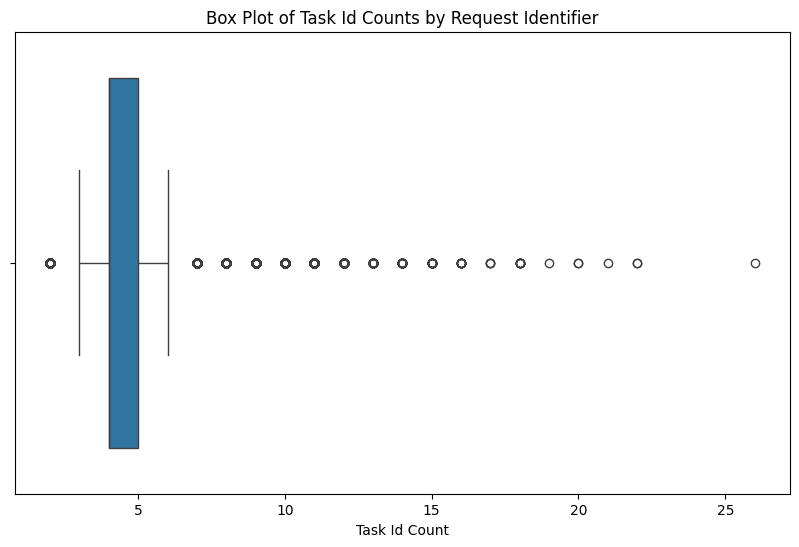

In [ ]:
# Plotting the box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=task_id_counts['Task Id Count'])

# Adding title and labels
plt.title('Box Plot of Task Id Counts by Request Identifier')
plt.xlabel('Task Id Count')

# Display the plot
plt.show()

In [ ]:
(len(task_id_counts[(task_id_counts['Task Id Count'] >= 9)]['Request Identifier'].unique())/len(df['Request Identifier'].unique()))*100

2.186019996491843

In [ ]:
#Filtering out the outliers from df
df = df[df['Request Identifier'].isin(task_id_counts[(task_id_counts['Task Id Count'] <= 9)]['Request Identifier'].unique())]

## 7.3 Inconsistencies

- IsOutSourcer:
Double-check, because in the Task Analysis and Resolve there might be people who are not outsourcers.
Ver se as atividades 102, 106 e 108 são sempre feitas por outsourcers.





In [ ]:
# Filter for specified Activity IDs
activity_filter = df['Actvity ID'].isin([102, 106, 108])

# Further filter for IsOutSourcer being 'N'
outsourcer_filter = df['IsOutSourcer'] == 'N'

# Apply both filters
df[activity_filter & outsourcer_filter]

,Task Id,Request Identifier,Task arrival date,Task capture date,Task execution end date,Task predicted end date,Actvity ID,Task Executer,Task executer department,Task Type,...,idField_3486,idField_3491,idField_3935,idBPMRequirement_183,idBPMRequirement_191,idBPMRequirement_300,idBPMRequirement_331,idBPMRequirement_353,idBPMRequirement_661,idBPMRequirement_1436
11,1589362,3,2022-04-12 18:09:29.607,2022-04-13 13:16:14.933,2022-04-13 13:16:14.933,2022-04-13 15:30:00.690,102,11029.0,167.0,Execution,...,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13,1589606,4,2022-04-13 08:15:40.310,2022-04-20 15:01:27.830,2022-04-20 15:02:55.463,2022-04-13 15:30:00.377,102,538.0,1301.0,Execution,...,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14,1606251,4,2022-04-20 15:02:55.713,2022-04-21 09:45:54.533,2022-04-21 11:54:31.433,2022-04-13 15:30:00.377,102,507.0,1336.0,Execution,...,1,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
17,1589670,5,2022-04-13 08:37:36.070,2022-04-21 09:51:02.400,2022-04-21 16:42:48.817,2022-04-13 15:37:36.137,102,507.0,1336.0,Execution,...,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22,1590085,6,2022-04-13 09:46:19.253,2022-04-21 09:53:23.303,2022-04-28 11:26:00.490,2022-04-13 16:46:19.393,102,507.0,1336.0,Execution,...,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208200,6626536,45767,2024-04-01 09:04:40.833,2024-04-01 09:30:23.637,2024-04-01 10:20:51.140,2024-04-01 16:04:40.947,102,11193.0,1147.0,Execution,...,1,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
208206,6626916,45768,2024-04-01 09:34:05.610,2024-04-01 10:50:30.103,2024-04-03 09:13:03.270,2024-04-01 16:08:16.280,102,10606.0,1147.0,Execution,...,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
208218,6628353,45770,2024-04-01 10:51:50.633,2024-04-01 11:17:40.193,2024-04-01 11:22:17.027,2024-04-01 16:45:07.023,102,10606.0,1147.0,Execution,...,1,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
208222,6728665,45771,2024-04-15 18:16:21.570,2024-04-16 08:18:47.537,2024-04-16 08:21:00.047,2024-04-16 15:30:00.643,102,8548.0,1147.0,Execution,...,1,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
(len(df[activity_filter & outsourcer_filter]['Request Identifier'].unique())/len(df['Request Identifier'].unique()))*100

19.263122849850184

In [ ]:
# Filter for specified Activity IDs
activity_filter = df['Actvity ID'].isin([100, 101, 104, 105, 107, 103])

# Further filter for IsOutSourcer being 'N'
outsourcer_filter = df['IsOutSourcer'] == 'Y'

# Apply both filters
df[activity_filter & outsourcer_filter]

,Task Id,Request Identifier,Task arrival date,Task capture date,Task execution end date,Task predicted end date,Actvity ID,Task Executer,Task executer department,Task Type,...,idField_3486,idField_3491,idField_3935,idBPMRequirement_183,idBPMRequirement_191,idBPMRequirement_300,idBPMRequirement_331,idBPMRequirement_353,idBPMRequirement_661,idBPMRequirement_1436
12275,1882388,2726,2022-06-22 14:49:57.630,2022-06-22 14:49:57.630,2022-06-22 14:49:57.630,2022-06-22 14:49:57.630,100,4322.0,1104.0,Initial Request,...,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12278,1891376,2726,2022-06-24 13:59:28.150,2022-08-22 04:20:40.750,2022-08-22 19:51:01.530,2022-06-27 11:59:28.247,104,4322.0,1104.0,Execution,...,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12285,1882416,2728,2022-06-22 14:52:23.360,2022-06-22 14:52:23.360,2022-06-22 14:52:23.360,2022-06-22 14:52:23.360,100,4322.0,1104.0,Initial Request,...,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12288,1893429,2728,2022-06-27 08:54:48.723,2022-06-27 09:08:24.007,2022-06-29 10:58:33.850,2022-06-27 15:54:48.880,104,4731.0,1104.0,Execution,...,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12346,1883239,2742,2022-06-22 16:24:44.923,2022-06-22 16:24:44.923,2022-06-22 16:24:44.923,2022-06-22 16:24:44.923,100,4322.0,1104.0,Initial Request,...,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12349,1891393,2742,2022-06-24 14:04:03.390,2022-08-22 04:23:20.250,2022-08-22 19:51:37.580,2022-06-27 12:04:03.587,104,4322.0,1104.0,Execution,...,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12569,1887522,2795,2022-06-23 14:09:12.800,2022-06-23 14:09:12.800,2022-06-23 14:09:12.800,2022-06-23 14:09:12.800,100,4322.0,1104.0,Initial Request,...,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12572,1892152,2795,2022-06-24 16:02:11.670,2022-08-22 13:06:00.087,2022-08-22 19:52:30.350,2022-06-27 14:02:11.783,104,4322.0,1104.0,Execution,...,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12584,1887630,2798,2022-06-23 14:31:06.390,2022-06-23 14:31:06.390,2022-06-23 14:31:06.390,2022-06-23 14:31:06.390,100,4322.0,1104.0,Initial Request,...,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12587,1891353,2798,2022-06-24 13:53:50.857,2022-08-22 04:18:41.753,2022-08-22 19:49:52.713,2022-06-27 11:53:51.013,104,4322.0,1104.0,Execution,...,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


- Having the same executer for all the tasks within the same case.  


All the following cases have executers that left the company, so no inconsistencies were found.

In [ ]:
# Group by 'Request Identifier' and count the unique 'Task Executer' within each group
task_executer_counts = task_execution_data.groupby('Request Identifier')['Task Executer'].nunique()

# Filter for Request Identifiers where there is only one unique Task Executer
request_ids_same_executer = task_executer_counts[task_executer_counts == 1].index.tolist()

# Filter for the request identifiers that have more than two tasks
task_counts_per_request = task_execution_data['Request Identifier'].value_counts()
request_ids_more_than_2_tasks = task_counts_per_request[task_counts_per_request > 2].index.tolist()

# Filter for the request identifiers that satisfy both conditions
filtered_request_identifiers = list(set(request_ids_same_executer) & set(request_ids_more_than_2_tasks))

# Display the Request Identifiers where all tasks are executed by the same Task Executer and have more than two tasks
if filtered_request_identifiers:
    print("Request Identifiers where all tasks are executed by the same Task Executer and have more than two tasks:")
    print(filtered_request_identifiers)
else:
    print("No Request Identifiers found that meet the specified criteria.")

Request Identifiers where all tasks are executed by the same Task Executer and have more than two tasks:
[16036, 13797, 20520, 17715, 19924, 16410]


## 7.4 Feature Engineering

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 201832 entries, 0 to 208230
Data columns (total 36 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Task Id                   201832 non-null  int64  
 1   Request Identifier        201832 non-null  int64  
 2   Task arrival date         201832 non-null  object 
 3   Task capture date         201832 non-null  object 
 4   Task execution end date   201832 non-null  object 
 5   Task predicted end date   201832 non-null  object 
 6   Actvity ID                201832 non-null  int64  
 7   Task Executer             201832 non-null  float64
 8   Task executer department  201832 non-null  float64
 9   Task Type                 201832 non-null  object 
 10  Action                    201832 non-null  object 
 11  idBPMApplicationAction    201832 non-null  int64  
 12  Sex                       201832 non-null  object 
 13  BirthYear                 201832 non-null  int64 

- Columns representing *idBPMRequirement* transformed to integer.

In [ ]:
# List of columns to transform
columns_to_transform = [
    'idBPMRequirement_183',
    'idBPMRequirement_191',
    'idBPMRequirement_300',
    'idBPMRequirement_331',
    'idBPMRequirement_353',
    'idBPMRequirement_661',
    'idBPMRequirement_1436'
]

# Transform specified columns to integer
df[columns_to_transform] = df[columns_to_transform].astype(int)

- *Task Executer* and *Task executer department* are always integer.

In [ ]:
df['Task Executer'] = df['Task Executer'].astype(int)
df['Task executer department'] = df['Task executer department'].astype(int)

- Dates are type object, but should be datetime.


In [ ]:
df['Task arrival date'] = pd.to_datetime(df['Task arrival date'])
df['Task capture date'] = pd.to_datetime(df['Task capture date'])
df['Task execution end date'] = pd.to_datetime(df['Task execution end date'])
df['Task predicted end date'] = pd.to_datetime(df['Task predicted end date'])

- Rename *Actvity ID* to *Activity ID* and *Sex* to *Gender*.

In [ ]:
df.rename(columns={'Actvity ID': 'Activity ID', 'Sex': 'Gender'}, inplace=True)

- **Age**: Age of the user calculated based on the *BirthYear*.

In [ ]:
# Get the current year
current_year = datetime.now().year

# Calculate the age
df['Age'] = current_year - df['BirthYear']

In [ ]:
#Drop BirthYear
df.drop(columns=['BirthYear'], inplace=True)

- **Organization Seniority**: Number of years that user is in the department.


In [ ]:
# Calculate the age
df['Organization Seniority'] = current_year - df['OrgUnitSince']

In [ ]:
#Drop OrgUnitSince
df.drop(columns=['OrgUnitSince'], inplace=True)

- **Recent Employee**: Binary variable that takes value 1 if the user has is in the company for less than (or equal) a year (*Department Seniority <= 1*)

In [ ]:
df['Recent Employee'] = (df['Organization Seniority'] <= 1).astype(int)

- **Task On Time**: Binary variable that takes value 1 if execution end data is earlier or equal to the predicted end date, and 0 otherwise.

In [ ]:
# Create the 'On Time' column
df['Task On Time'] = (df['Task execution end date'] <= df['Task predicted end date']).astype(int)

In [ ]:
#Check missing values
round(df.isna().sum()/len(df),4)*100

Task Id                     0.0
Request Identifier          0.0
Task arrival date           0.0
Task capture date           0.0
Task execution end date     0.0
Task predicted end date     0.0
Activity ID                 0.0
Task Executer               0.0
Task executer department    0.0
Task Type                   0.0
Action                      0.0
idBPMApplicationAction      0.0
Gender                      0.0
Role ID                     0.0
Is Manager                  0.0
IsOutSourcer                0.0
idField_47                  0.0
idField_203                 0.0
idField_1602                0.0
idField_1604                0.0
idField_3388                0.0
idField_3390                0.0
idField_3391                0.0
idField_3420                0.0
idField_3486                0.0
idField_3491                0.0
idField_3935                0.0
idBPMRequirement_183        0.0
idBPMRequirement_191        0.0
idBPMRequirement_300        0.0
idBPMRequirement_331        0.0
idBPMReq

* **Task Duration**: Time between the execution end date and the capture date.

In [ ]:
df['Task Duration'] = (pd.to_datetime(df['Task execution end date']) - pd.to_datetime(df['Task capture date'])).dt.days

* **Execution to Predicted Diff**: Difference between execution and prediction.

In [ ]:
df['Execution to Predicted Diff'] = (pd.to_datetime(df['Task execution end date']) - pd.to_datetime(df['Task predicted end date'])).dt.days

* **Pass in 101**: Binary variable that takes value 1 when it at some point goes to “Review Request (101)”, even if it ends with success, and 0 otherwise.




In [ ]:
df['Contains 101'] = df.groupby('Request Identifier')['Activity ID'].transform(lambda x: 1 if 101 in x.values else 0)

## 7.5 Feature Encoding

* Remove Action and Task ID, because they don't add new and useful information. Action is represented by idBPMApplicationAction.

In [ ]:
df.drop(columns=['Action'], inplace=True)

In [ ]:
df.drop(columns=['Task Id'], inplace=True)

- Task Type

In [ ]:
df['Task Type'].unique()

array(['Initial Request', 'Execution', 'Final task',
       'Requester response to rejection'], dtype=object)

In [ ]:
# Define the order of the categories
category_order = ['Initial Request', 'Execution', 'Requester response to rejection', 'Final task']

# Create a mapping dictionary
category_mapping = {category: index for index, category in enumerate(category_order)}

# Apply the mapping to the data
df['Task Type'] = df['Task Type'].map(category_mapping)

- Gender

In [ ]:
df['Gender'].unique()

array(['M', 'F'], dtype=object)

In [ ]:
# Initialize the LabelEncoder
le = LabelEncoder()

# Fit and transform the data
df['Gender'] = le.fit_transform(df['Gender'])

df = df.rename(columns={'Gender': 'Male'})

- IsOutSourcer: if 'Y' returns 1, otherwise it returns 0.

In [ ]:
df['IsOutSourcer'].unique()

array(['N', 'Y'], dtype=object)

In [ ]:
df['IsOutSourcer'] = le.fit_transform(df['IsOutSourcer'])


- Is Manager: if 'Yes' returns 1, otherwise it returns 0.

In [ ]:
df['Is Manager'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df['Is Manager'] = le.fit_transform(df['Is Manager'])

# 8. Visualizations

Visualizations were done in PowerBi and you can find them here. FALTA LINK

# 9. Target Column

Creating the target column where:
- 0: Request canceled
- 1: Request finished
- 2: Closed administratively requester reject accounting impact
- 3: Closed administratively

In [ ]:
df = df.sort_values(by=['Request Identifier', 'Task arrival date'], ascending=[True, True])

In [ ]:
df

,Request Identifier,Task arrival date,Task capture date,Task execution end date,Task predicted end date,Activity ID,Task Executer,Task executer department,Task Type,idBPMApplicationAction,...,idBPMRequirement_353,idBPMRequirement_661,idBPMRequirement_1436,Age,Organization Seniority,Recent Employee,Task On Time,Task Duration,Execution to Predicted Diff,Contains 101
0,1,2022-04-11 16:02:13.820,2022-04-11 16:02:13.820,2022-04-11 16:02:13.820,2022-04-11 16:02:13.820,100,7638,569,0,270,...,0,0,0,57,3,0,1,0,0,0
1,1,2022-04-11 16:02:14.743,2022-04-12 09:29:40.683,2022-04-12 10:02:54.687,2022-04-12 14:02:14.803,102,4322,1104,1,273,...,0,0,0,57,0,1,1,0,-1,0
2,1,2022-04-12 10:02:55.530,2022-04-12 10:14:39.290,2022-04-12 10:17:16.050,2022-04-12 17:02:55.577,103,10606,1147,1,273,...,0,0,0,49,1,1,1,0,-1,0
3,1,2022-04-12 10:17:16.427,2022-04-12 10:22:47.610,2022-05-10 13:43:32.203,2022-04-12 17:17:16.490,104,7638,569,1,282,...,0,0,0,57,3,0,0,28,27,0
4,1,2022-05-10 13:43:32.627,2022-05-10 13:47:53.570,2022-05-10 13:48:44.353,2022-05-17 08:43:32.737,107,7638,569,3,299,...,0,0,0,57,3,0,1,0,-7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208226,45772,2024-05-03 15:33:44.133,2024-05-03 16:28:37.080,2024-05-03 16:42:52.420,2024-05-06 13:33:44.180,102,10606,1147,1,273,...,0,0,0,49,1,1,1,0,-3,0
208227,45772,2024-05-03 16:42:52.653,2024-05-03 17:44:10.993,2024-05-03 17:44:40.083,2024-05-06 14:42:52.717,103,10606,1147,1,300,...,0,0,0,49,1,1,1,0,-3,0
208228,45772,2024-05-03 17:44:40.853,2024-05-06 09:10:57.097,2024-05-06 09:11:24.433,2024-05-06 15:30:00.977,104,2243,722,1,290,...,0,0,0,25,1,1,1,0,-1,0
208229,45772,2024-05-06 09:11:25.000,2024-05-07 08:30:44.273,2024-05-07 08:31:28.600,2024-05-06 15:30:00.977,104,92,722,1,282,...,0,0,0,48,6,0,0,0,0,0


In [ ]:
# Get the most recent row for each 'Request Identifier'
recent_rows = df.drop_duplicates(subset=['Request Identifier'], keep='last').copy()

In [ ]:
recent_rows[(recent_rows['Activity ID']==102) & (recent_rows['idBPMApplicationAction']==298)]

,Request Identifier,Task arrival date,Task capture date,Task execution end date,Task predicted end date,Activity ID,Task Executer,Task executer department,Task Type,idBPMApplicationAction,...,idBPMRequirement_353,idBPMRequirement_661,idBPMRequirement_1436,Age,Organization Seniority,Recent Employee,Task On Time,Task Duration,Execution to Predicted Diff,Contains 101
11,3,2022-04-12 18:09:29.607,2022-04-13 13:16:14.933,2022-04-13 13:16:14.933,2022-04-13 15:30:00.690,102,11029,167,1,298,...,0,0,0,49,3,0,1,0,-1,0
4436,981,2022-05-20 09:55:17.057,2022-05-20 10:41:49.123,2022-05-20 10:41:49.123,2022-05-20 16:55:17.217,102,10309,251,1,298,...,0,0,0,49,3,0,1,0,-1,0
4897,1084,2022-05-23 11:46:52.747,2022-05-23 13:57:43.030,2022-05-23 13:57:43.047,2022-05-24 09:46:52.863,102,12000,12000,1,298,...,0,0,0,91,1,1,1,0,-1,0
5823,1285,2022-05-26 11:31:12.703,2022-06-01 09:58:30.787,2022-06-01 09:58:30.787,2022-05-27 09:31:12.840,102,10718,577,1,298,...,0,0,0,48,0,1,0,0,5,0
7903,1746,2022-06-03 09:01:19.330,2022-06-06 17:32:42.037,2022-06-06 17:32:42.050,2022-06-03 16:01:19.437,102,8576,711,1,298,...,0,0,0,55,12,0,0,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200453,44274,2024-02-22 12:13:44.350,2024-02-22 12:24:32.000,2024-02-22 12:24:32.000,2024-02-23 10:13:44.497,102,1726,681,1,298,...,0,0,0,27,5,0,1,0,-1,0
201124,44396,2024-02-26 14:52:23.240,2024-02-26 15:46:36.270,2024-02-26 15:46:36.270,2024-02-27 12:52:23.337,102,9953,577,1,298,...,0,0,0,49,1,1,1,0,-1,0
202580,44674,2024-03-04 09:37:50.293,2024-03-04 09:47:20.393,2024-03-04 09:47:20.397,2024-03-04 16:37:50.407,102,10169,80,1,298,...,0,0,0,48,4,0,1,0,-1,0
202654,44690,2024-03-04 10:52:57.690,2024-03-04 11:06:37.237,2024-03-04 11:06:37.237,2024-03-05 08:52:57.817,102,7847,234,1,298,...,0,0,0,52,4,0,1,0,-1,0


In [ ]:
# Define the function to determine the target value
def determine_target(action, activity):
    if action in [298, 2981] and activity == 101:
        return 0
    elif action == 298 and activity in [102, 105]:
        return 0
    elif action == 299 and activity == 107:
        return 1
    elif action == 8888 and activity == 104:
        return 2
    elif action in [8888, 888] and activity in [103, 106, 107, 108 ]:
        return 3

# Apply the function to create the 'Target' column for the most recent rows
recent_rows['Target'] = recent_rows.apply(lambda row: determine_target(row['idBPMApplicationAction'], row['Activity ID']), axis=1)

- Analyze cases that are left out from the target column. In this case, this will be considered an error and removed from the dataset, because it is assumed that this situation is not possible to happen.

In [ ]:
na = recent_rows[recent_rows['Target'].isna()==True]

# Group by 'Activity ID' and 'idBPMApplicationAction' and count the rows in each group
counts = na.groupby(['Activity ID', 'idBPMApplicationAction']).size().reset_index(name='Count')

# Display the result
print(counts)

   Activity ID  idBPMApplicationAction  Count
0          103                     300      1


In [ ]:
recent_rows[pd.isna(recent_rows['Target'])]

,Request Identifier,Task arrival date,Task capture date,Task execution end date,Task predicted end date,Activity ID,Task Executer,Task executer department,Task Type,idBPMApplicationAction,...,idBPMRequirement_661,idBPMRequirement_1436,Age,Organization Seniority,Recent Employee,Task On Time,Task Duration,Execution to Predicted Diff,Contains 101,Target
30753,6897,2022-08-23 20:27:15.240,2022-08-23 20:27:15.240,2022-08-24 14:11:52.030,2022-08-25 12:11:52.490,103,10606,1147,1,300,...,0,0,49,1,1,1,0,-1,0,NaN


In [ ]:
df = df.merge(recent_rows[['Request Identifier', 'Target']], on='Request Identifier', how='left')

In [ ]:
df.reset_index(drop=True, inplace=True)

In [ ]:
# Removing the request identifier that is considered an error (i.e. Activity ID = 103 and idBPMApplicationAction = 300)
df = df[df['Request Identifier'] != 6897]

# 9. Market Basket analysis

In [ ]:
import pandas as pd

# Obter todos os identificadores únicos de solicitação
unique_request_ids = df['Request Identifier'].unique()

# Definir o tamanho da amostra (por exemplo, 40%)
sample_size = int(len(unique_request_ids) * 0.2)

# Amostrar aleatoriamente os identificadores de solicitação
sampled_request_ids = pd.Series(unique_request_ids).sample(n=sample_size, random_state=42)

# Selecionar todas as observações associadas aos identificadores de solicitação amostrados
sampled_data = df[df['Request Identifier'].isin(sampled_request_ids)]

# Verificar o tamanho da amostra
print("Tamanho da amostra:", len(sampled_data))

# Verificar a representatividade da amostra
print(sampled_data['Target'].value_counts())  # Verificar a distribuição das classes, se aplicável

Tamanho da amostra: 40211
Target
2.0    15360
3.0    14749
1.0     8748
0.0     1354
Name: count, dtype: int64


In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

# Select relevant attributes for analysis
attributes = ['Task Executer', 'Task executer department', 'Task Type', 'Male', 'Role ID', 'Is Manager',
              'IsOutSourcer', 'Age', 'Organization Seniority', 'Recent Employee']

In [ ]:
def frequent_itemsets_for_target(df, target_category, attributes, min_support=0.1):
    # Filter data for the given target category
    filtered_data = sampled_data[sampled_data['Target'] == target_category][attributes].applymap(str)

    # Convert data to a transactional format
    df_encoded = pd.get_dummies(filtered_data)

    # Apply Apriori algorithm to find frequent itemsets
    frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)

    return frequent_itemsets.sort_values(by='support', ascending=False)  # Sort by support in descending order

# Perform market basket analysis for each target category
results = {}
target_categories = sampled_data['Target'].unique()
for target_category in target_categories:
    frequent_itemsets = frequent_itemsets_for_target(sampled_data, target_category, attributes)
    results[target_category] = frequent_itemsets

# Display frequent itemsets for each target category sorted by support in descending order
for target_category, frequent_itemsets in results.items():
    print(f"Frequent Itemsets for Target Category {target_category}:")
    print(frequent_itemsets)
    print()

Frequent Itemsets for Target Category 1.0:
      support                                           itemsets
14   0.800069                                   (IsOutSourcer_0)
102  0.780636                     (IsOutSourcer_0, Is Manager_1)
13   0.780636                                     (Is Manager_1)
6    0.640947                                           (Male_0)
21   0.620485                                (Recent Employee_1)
..        ...                                                ...
42   0.101052                              (Male_0, Task Type_0)
465  0.100251  (Male_0, Task Type_3, Is Manager_1, IsOutSourc...
227  0.100251              (Male_0, Task Type_3, IsOutSourcer_0)
61   0.100251                              (Male_0, Task Type_3)
226  0.100251                (Male_0, Task Type_3, Is Manager_1)

[845 rows x 2 columns]

Frequent Itemsets for Target Category 2.0:
      support                                           itemsets
12   0.761328                               

# 10. Prefix-Length Bucketing
There will be 9 buckets, each one corresponding to the each prefix length. E.g. the first bucket combinates the first activity of all *Request Identifiers*.

In [ ]:
y = df.groupby('Request Identifier')['Target'].last().reset_index()

In [ ]:
y.set_index('Request Identifier', inplace=True)

In [ ]:
y

,Target
Request Identifier,
1,1.0
2,1.0
3,0.0
4,0.0
5,2.0
...,...
45768,3.0
45769,3.0
45770,1.0


In [ ]:
df = df.drop('Target', axis=1)

In [ ]:
# Initialize dictionaries to store rows for each bucket
buckets = {f'bucket{i}': [] for i in range(1, 11)}

# Group by 'Request Identifier'
grouped = df.groupby('Request Identifier')

# Iterate over each group
for name, group in grouped:
    sorted_group = group.sort_values(by='Task arrival date')
    for i in range(1, 10):
        if len(sorted_group) >= i:
            oldest_rows = sorted_group.head(i)
            buckets[f'bucket{i}'].append(oldest_rows)

# Create dataframes for each bucket
bucket_dfs = {bucket_name: pd.concat(bucket_rows) for bucket_name, bucket_rows in buckets.items() if bucket_rows}

In [ ]:
# Dynamically create variables for each bucket DataFrame
for key in bucket_dfs:
    globals()[f'{key}_df'] = bucket_dfs[key]

# Verify that the variables have been created correctly
for i in range(1, 10):
    var_name = f'bucket{i}_df'
    if var_name in globals():
        print(f"{var_name} has been created and has {len(globals()[var_name])} rows.")

bucket1_df has been created and has 45054 rows.
bucket2_df has been created and has 90108 rows.
bucket3_df has been created and has 134694 rows.
bucket4_df has been created and has 155136 rows.
bucket5_df has been created and has 94020 rows.
bucket6_df has been created and has 29412 rows.
bucket7_df has been created and has 18424 rows.
bucket8_df has been created and has 10048 rows.
bucket9_df has been created and has 3996 rows.


In [ ]:
len(bucket9_df['Request Identifier'].unique())

444

In [ ]:
len(bucket5_df.columns)

39

* Verify if the second activities of all buckets are 102 or 105:

In [ ]:
# Step 1: Group by 'Request Identifier' and get the last row of each group
last_rows = bucket2_df.groupby('Request Identifier').tail(1)

# Step 2: Check if 'Activity ID' in these rows is either 102 or 105
last_rows['Activity ID check'] = last_rows['Activity ID'].isin([102, 105])

In [ ]:
last_rows['Activity ID check'].unique()

array([ True])

- Verify if the first activities of all buckets is 100:

In [ ]:
# Step 1: Group by 'Request Identifier' and get the last row of each group
last_rows = bucket1_df.groupby('Request Identifier').tail(1)

# Step 2: Check if 'Activity ID' in these rows is 100
last_rows['Activity ID check'] = last_rows['Activity ID'].isin([100])

In [ ]:
last_rows['Activity ID check'].unique()

array([ True])

In [ ]:
df.shape

(201828, 39)

# 11. Sequence Encoding
Sequence encoding is the next step in Predictive Process Monitoring and concerns the encoding of the activities. The aim is that there is only one row per request identifier.

This step is going to be done for each bucket, because each bucket can contain different activities.

## 11.1 Complex Index Encoding

- Models do not support datetime data type columns. These columns will be removed because we already sorted the activities by date in bucketing.

In [ ]:
# List of columns to remove
columns_to_remove = ['Task arrival date', 'Task capture date', 'Task execution end date', 'Task predicted end date', 'Contains 101']

# Iterate through each dataset and remove the specified columns
for bucket_df in [bucket1_df, bucket2_df, bucket3_df, bucket4_df, bucket5_df, bucket6_df, bucket7_df, bucket8_df, bucket9_df]:
    bucket_df.drop(columns=columns_to_remove, inplace=True)

In [ ]:
df.shape

(201828, 39)

- Applying the encoding to Bucket 1

In [ ]:
bucket1_df = bucket1_df[['Request Identifier', 'Activity ID', 'Task Executer','Task executer department', 'Male', 'Role ID','idField_47', 'idField_1602', 'idField_3420', 'idField_3491','idField_3935']]
bucket1_df.set_index('Request Identifier', inplace = True)

  - Applying the encoding to each bucket.
    * The prediction will be made with certain information from the present.

In [ ]:
'''def process_bucket_present(bucket_df, num_rows):
    dfs = []
    for request_id, group_df in bucket_df.groupby('Request Identifier'):
        row_dfs = []
        for i in range(1, num_rows):
            if i == num_rows - 1:
                row = group_df.iloc[[-1]][['Request Identifier', 'Activity ID', 'Task Executer','Task executer department', 'Male', 'Role ID','idField_47', 'idField_1602', 'idField_3420', 'idField_3491','idField_3935']].add_suffix(f'_{i}')
            else:
                row = group_df.iloc[[0]].add_suffix(f'_{i}')
            row_dfs.append(row.reset_index(drop=True))

        # Concatenate rows for this group
        concatenated = pd.concat(row_dfs, axis=1)

        # Add Request Identifier_1 as index
        concatenated['Request Identifier_1'] = request_id
        concatenated = concatenated.set_index('Request Identifier_1')

        # Remove columns that start with 'Request Identifier_'
        concatenated = concatenated.loc[:, ~concatenated.columns.str.startswith('Request Identifier_')]

        dfs.append(concatenated)

    return pd.concat(dfs)'''

"def process_bucket_present(bucket_df, num_rows):\n    dfs = []\n    for request_id, group_df in bucket_df.groupby('Request Identifier'):\n        row_dfs = []\n        for i in range(1, num_rows):\n            if i == num_rows - 1:\n                row = group_df.iloc[[-1]][['Request Identifier', 'Activity ID', 'Task Executer','Task executer department', 'Male', 'Role ID','idField_47', 'idField_1602', 'idField_3420', 'idField_3491','idField_3935']].add_suffix(f'_{i}')\n            else:\n                row = group_df.iloc[[0]].add_suffix(f'_{i}')\n            row_dfs.append(row.reset_index(drop=True))\n\n        # Concatenate rows for this group\n        concatenated = pd.concat(row_dfs, axis=1)\n\n        # Add Request Identifier_1 as index\n        concatenated['Request Identifier_1'] = request_id\n        concatenated = concatenated.set_index('Request Identifier_1')\n\n        # Remove columns that start with 'Request Identifier_'\n        concatenated = concatenated.loc[:, ~conca

In [ ]:
'''# Process each bucket individually
bucket2_df_present = process_bucket_present(bucket2_df, 3)
bucket3_df_present = process_bucket_present(bucket3_df, 4)
bucket4_df_present = process_bucket_present(bucket4_df, 5)
bucket5_df_present = process_bucket_present(bucket5_df, 6)
bucket6_df_present = process_bucket_present(bucket6_df, 7)
bucket7_df_present = process_bucket_present(bucket7_df, 8)
bucket8_df_present = process_bucket_present(bucket8_df, 9)
bucket9_df_present = process_bucket_present(bucket9_df, 10)'''

'# Process each bucket individually\nbucket2_df_present = process_bucket_present(bucket2_df, 3)\nbucket3_df_present = process_bucket_present(bucket3_df, 4)\nbucket4_df_present = process_bucket_present(bucket4_df, 5)\nbucket5_df_present = process_bucket_present(bucket5_df, 6)\nbucket6_df_present = process_bucket_present(bucket6_df, 7)\nbucket7_df_present = process_bucket_present(bucket7_df, 8)\nbucket8_df_present = process_bucket_present(bucket8_df, 9)\nbucket9_df_present = process_bucket_present(bucket9_df, 10)'

In [ ]:
'''bucket2_df_present.to_excel('bucket2_df_present.xlsx', index=True)
bucket3_df_present.to_excel('bucket3_df_present.xlsx', index=True)
bucket4_df_present.to_excel('bucket4_df_present.xlsx', index=True)
bucket5_df_present.to_excel('bucket5_df_present.xlsx', index=True)
bucket6_df_present.to_excel('bucket6_df_present.xlsx', index=True)
bucket7_df_present.to_excel('bucket7_df_present.xlsx', index=True)
bucket8_df_present.to_excel('bucket8_df_present.xlsx', index=True)
bucket9_df_present.to_excel('bucket9_df_present.xlsx', index=True)'''

"bucket2_df_present.to_excel('bucket2_df_present.xlsx', index=True)\nbucket3_df_present.to_excel('bucket3_df_present.xlsx', index=True)\nbucket4_df_present.to_excel('bucket4_df_present.xlsx', index=True)\nbucket5_df_present.to_excel('bucket5_df_present.xlsx', index=True)\nbucket6_df_present.to_excel('bucket6_df_present.xlsx', index=True)\nbucket7_df_present.to_excel('bucket7_df_present.xlsx', index=True)\nbucket8_df_present.to_excel('bucket8_df_present.xlsx', index=True)\nbucket9_df_present.to_excel('bucket9_df_present.xlsx', index=True)"

# Dataset Split

- As encoding the bucket takes much computational power, we decided to export each bucket to avoid running the buckets every time we have to run the code.

In [ ]:
# Load the data from the Excel files
bucket2_df_present = pd.read_excel('bucket2_df_present.xlsx')
bucket3_df_present = pd.read_excel('bucket3_df_present.xlsx')
bucket4_df_present = pd.read_excel('bucket4_df_present.xlsx')
bucket5_df_present = pd.read_excel('bucket5_df_present.xlsx')
bucket6_df_present = pd.read_excel('bucket6_df_present.xlsx')
bucket7_df_present = pd.read_excel('bucket7_df_present.xlsx')
bucket8_df_present = pd.read_excel('bucket8_df_present.xlsx')
bucket9_df_present = pd.read_excel('bucket9_df_present.xlsx')

In [ ]:
bucket2_df_present.columns

Index(['Request Identifier_1', 'Activity ID_1', 'Task Executer_1',
       'Task executer department_1', 'Task Type_1', 'idBPMApplicationAction_1',
       'Male_1', 'Role ID_1', 'Is Manager_1', 'IsOutSourcer_1', 'idField_47_1',
       'idField_203_1', 'idField_1602_1', 'idField_1604_1', 'idField_3388_1',
       'idField_3390_1', 'idField_3391_1', 'idField_3420_1', 'idField_3486_1',
       'idField_3491_1', 'idField_3935_1', 'idBPMRequirement_183_1',
       'idBPMRequirement_191_1', 'idBPMRequirement_300_1',
       'idBPMRequirement_331_1', 'idBPMRequirement_353_1',
       'idBPMRequirement_661_1', 'idBPMRequirement_1436_1', 'Age_1',
       'Organization Seniority_1', 'Recent Employee_1', 'Task On Time_1',
       'Task Duration_1', 'Execution to Predicted Diff_1', 'Activity ID_2',
       'Task Executer_2', 'Task executer department_2', 'Male_2', 'Role ID_2',
       'idField_47_2', 'idField_1602_2', 'idField_3420_2', 'idField_3491_2',
       'idField_3935_2'],
      dtype='object')

In [ ]:
bucket9_df_present['Request Identifier_1']

0        842
1       1065
2       1397
3       1404
4       1700
       ...  
439    45570
440    45633
441    45672
442    45695
443    45759
Name: Request Identifier_1, Length: 444, dtype: int64

In [ ]:
bucket2_df_present.set_index('Request Identifier_1', inplace=True)
bucket3_df_present.set_index('Request Identifier_1', inplace=True)
bucket4_df_present.set_index('Request Identifier_1', inplace=True)
bucket5_df_present.set_index('Request Identifier_1', inplace=True)
bucket6_df_present.set_index('Request Identifier_1', inplace=True)
bucket7_df_present.set_index('Request Identifier_1', inplace=True)
bucket8_df_present.set_index('Request Identifier_1', inplace=True)
bucket9_df_present.set_index('Request Identifier_1', inplace=True)

An imbalanced dataset typically means that the class distribution is significantly skewed, with one or more classes being underrepresented relative to others. Given the following proportions, we can conclude that the target distribution is imbalanced.
- Class 0.0 (4.2%) is significantly underrepresented compared to the others.
- Class 1.0 (19.6%) is also less represented compared to classes 2.0 and 3.0.
- Classes 2.0 (43.3%) and 3.0 (32.9%) are the majority classes and have a more balanced representation relative to each other.


In [ ]:
y.value_counts()

Target
2.0       19498
3.0       14815
1.0        8836
0.0        1905
Name: count, dtype: int64

For 2nd perspective that uses some information from the present:

In [ ]:
from sklearn.model_selection import train_test_split

# Define the sizes for the splits
train_size = 0.6
temp_size = 0.4  # This is 40%, which will be split into 20% validation and 20% test
val_size = 0.5   # This is 50% of the temporary set, i.e., 20% of the original data
test_size = 0.5  # This is 50% of the temporary set, i.e., 20% of the original data

# Iterate through each dataset and perform the splits
for i, bucket_df_present in enumerate([bucket1_df, bucket2_df_present, bucket3_df_present, bucket4_df_present, bucket5_df_present, bucket6_df_present, bucket7_df_present, bucket8_df_present, bucket9_df_present], start=1):
    # Split the dataset into train and temporary sets
    X_train_present, X_temp_present = train_test_split(bucket_df_present, train_size=train_size, random_state=42)

    # Split the temporary set into validation and test sets
    X_val_present, X_test_present = train_test_split(X_temp_present, test_size=test_size, random_state=42)

    # Assign the splits to variables dynamically
    globals()[f"X_train_{i}_present"] = X_train_present
    globals()[f"X_val_{i}_present"] = X_val_present
    globals()[f"X_test_{i}_present"] = X_test_present

In [ ]:
datasets_present = [bucket1_df, bucket2_df_present, bucket3_df_present, bucket4_df_present, bucket5_df_present, bucket6_df_present, bucket7_df_present, bucket8_df_present, bucket9_df_present]
train_sets_present = [X_train_1_present, X_train_2_present, X_train_3_present, X_train_4_present, X_train_5_present, X_train_6_present, X_train_7_present, X_train_8_present, X_train_9_present]
val_sets_present = [X_val_1_present, X_val_2_present, X_val_3_present, X_val_4_present, X_val_5_present, X_val_6_present, X_val_7_present, X_val_8_present, X_val_9_present]
test_sets_present = [X_test_1_present, X_test_2_present, X_test_3_present, X_test_4_present, X_test_5_present, X_test_6_present, X_test_7_present, X_test_8_present, X_test_9_present]

for i, dataset_present in enumerate(datasets_present):
    train_indexes_present = train_sets_present[i].index
    val_indexes_present = val_sets_present[i].index
    test_indexes_present = test_sets_present[i].index

    y_train_present = y[y.index.isin(train_indexes_present)]
    y_val_present = y[y.index.isin(val_indexes_present)]
    y_test_present = y[y.index.isin(test_indexes_present)]

    # Dynamically create variable names
    globals()[f"y_train_{i+1}_present"] = y_train_present
    globals()[f"y_val_{i+1}_present"] = y_val_present
    globals()[f"y_test_{i+1}_present"] = y_test_present

In [ ]:
y_train_sets_present = [y_train_1_present, y_train_2_present, y_train_3_present, y_train_4_present, y_train_5_present, y_train_6_present, y_train_7_present, y_train_8_present, y_train_9_present]
y_val_sets_present = [y_val_1_present, y_val_2_present, y_val_3_present, y_val_4_present, y_val_5_present, y_val_6_present, y_val_7_present, y_val_8_present, y_val_9_present]
y_test_sets_present = [y_test_1_present, y_test_2_present, y_test_3_present, y_test_4_present, y_test_5_present, y_test_6_present, y_test_7_present, y_test_8_present, y_test_9_present]

## 11.2 Loading Buckets

- As encoding the bucket takes much computational power, we decided to export each bucket to avoid running the buckets every time we have to run the code.

In [ ]:
# bucket1_df = pd.read_excel('bucket1_df.xlsx')
# bucket1_df.set_index('Request Identifier', inplace = True)
# bucket2_df = pd.read_excel('bucket2_df.xlsx')
# bucket2_df.set_index('Request Identifier_1', inplace = True)
# bucket3_df = pd.read_excel('bucket3_df.xlsx')
# bucket3_df.set_index('Request Identifier_1', inplace = True)
# bucket4_df = pd.read_excel('bucket4_df.xlsx')
# bucket4_df.set_index('Request Identifier_1', inplace = True)
# bucket5_df = pd.read_excel('bucket5_df.xlsx')
# bucket5_df.set_index('Request Identifier_1', inplace = True)
# bucket6_df = pd.read_excel('bucket6_df.xlsx')
# bucket6_df.set_index('Request Identifier_1', inplace = True)
# bucket7_df = pd.read_excel('bucket7_df.xlsx')
# bucket7_df.set_index('Request Identifier_1', inplace = True)
# bucket8_df = pd.read_excel('bucket8_df.xlsx')
# bucket8_df.set_index('Request Identifier_1', inplace = True)
# bucket9_df = pd.read_excel('bucket9_df.xlsx')
# bucket9_df.set_index('Request Identifier_1', inplace = True)

# 13. Buckets Feature Selection

## 13.1 Datasets Scaling

### 13.1.1 Standard Scaler

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# Initialize StandardScaler
scaler = StandardScaler()

# Create empty lists to store the scaled datasets
train_sets_scaled_present = []
val_sets_scaled_present = []
test_sets_scaled_present = []

# Loop through each pair of training, validation, and test datasets
for idx, (X_train_present, X_val_present, X_test_present) in enumerate(zip(train_sets_present, val_sets_present, test_sets_present), start=1):
    # Identify columns to scale
    columns_to_exclude = [col for col in X_train_present.columns if col.startswith("Activity ID") or col.startswith("idBPMApplicationAction")]
    columns_to_scale = [col for col in X_train_present.columns if col not in columns_to_exclude]

    # Extract the columns to scale
    X_train_subset_present = X_train_present[columns_to_scale]
    X_val_subset_present = X_val_present[columns_to_scale]
    X_test_subset_present = X_test_present[columns_to_scale]

    # Fit scaler on the training subset and transform training, validation, and test subsets
    X_train_scaled_subset_present = scaler.fit_transform(X_train_subset_present)
    X_val_scaled_subset_present = scaler.transform(X_val_subset_present)
    X_test_scaled_subset_present = scaler.transform(X_test_subset_present)

    # Create DataFrames with the scaled columns
    X_train_scaled_df_present = pd.DataFrame(X_train_scaled_subset_present, columns=columns_to_scale, index=X_train_present.index)
    X_val_scaled_df_present = pd.DataFrame(X_val_scaled_subset_present, columns=columns_to_scale, index=X_val_present.index)
    X_test_scaled_df_present = pd.DataFrame(X_test_scaled_subset_present, columns=columns_to_scale, index=X_test_present.index)

    # Combine the scaled columns with the excluded columns
    X_train_scaled_present = X_train_present.copy()
    X_val_scaled_present = X_val_present.copy()
    X_test_scaled_present = X_test_present.copy()
    X_train_scaled_present[columns_to_scale] = X_train_scaled_df_present
    X_val_scaled_present[columns_to_scale] = X_val_scaled_df_present
    X_test_scaled_present[columns_to_scale] = X_test_scaled_df_present

    # Store the scaled datasets in the respective lists
    train_sets_scaled_present.append(X_train_scaled_present)
    val_sets_scaled_present.append(X_val_scaled_present)
    test_sets_scaled_present.append(X_test_scaled_present)

    # Optionally, store scaled datasets with appropriate global variable names
    globals()[f'X_train_{idx}_standard_present'] = X_train_scaled_present
    globals()[f'X_val_{idx}_standard_present'] = X_val_scaled_present
    globals()[f'X_test_{idx}_standard_present'] = X_test_scaled_present

In [ ]:
train_sets_standard_present = [X_train_1_standard_present, X_train_2_standard_present, X_train_3_standard_present, X_train_4_standard_present, X_train_5_standard_present, X_train_6_standard_present, X_train_7_standard_present, X_train_8_standard_present, X_train_9_standard_present]
val_sets_standard_present = [X_val_1_standard_present, X_val_2_standard_present, X_val_3_standard_present, X_val_4_standard_present, X_val_5_standard_present, X_val_6_standard_present, X_val_7_standard_present, X_val_8_standard_present, X_val_9_standard_present]
test_sets_standard_present = [X_test_1_standard_present, X_test_2_standard_present, X_test_3_standard_present, X_test_4_standard_present, X_test_5_standard_present, X_test_6_standard_present, X_test_7_standard_present, X_test_8_standard_present, X_test_9_standard_present]


### 13.1.2 MinMax Scaler

In [ ]:
# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Loop through each pair of training, validation, and test datasets
for idx, (X_train_present, X_val_present, X_test_present) in enumerate(zip(train_sets_present, val_sets_present, test_sets_present), start=1):
    # Identify columns to scale
    columns_to_exclude = [col for col in X_train_present.columns if col.startswith("Activity ID") or col.startswith("idBPMApplicationAction")]
    columns_to_scale = [col for col in X_train_present.columns if col not in columns_to_exclude]

    # Extract the columns to scale
    X_train_subset_present = X_train_present[columns_to_scale]
    X_val_subset_present = X_val_present[columns_to_scale]
    X_test_subset_present = X_test_present[columns_to_scale]

    # Fit scaler on the training subset and transform both training, validation, and test subsets
    X_train_scaled_subset_present = scaler.fit_transform(X_train_subset_present)
    X_val_scaled_subset_present = scaler.transform(X_val_subset_present)
    X_test_scaled_subset_present = scaler.transform(X_test_subset_present)

    # Create DataFrames with the scaled columns
    X_train_scaled_df_present = pd.DataFrame(X_train_scaled_subset_present, columns=columns_to_scale, index=X_train_present.index)
    X_val_scaled_df_present = pd.DataFrame(X_val_scaled_subset_present, columns=columns_to_scale, index=X_val_present.index)
    X_test_scaled_df_present = pd.DataFrame(X_test_scaled_subset_present, columns=columns_to_scale, index=X_test_present.index)

    # Combine the scaled columns with the excluded columns
    X_train_scaled_present = X_train_present.copy()
    X_val_scaled_present = X_val_present.copy()
    X_test_scaled_present = X_test_present.copy()
    X_train_scaled_present[columns_to_scale] = X_train_scaled_df_present
    X_val_scaled_present[columns_to_scale] = X_val_scaled_df_present
    X_test_scaled_present[columns_to_scale] = X_test_scaled_df_present

    # Store scaled datasets with appropriate names
    globals()[f'X_train_{idx}_scaled_present'] = X_train_scaled_present
    globals()[f'X_val_{idx}_scaled_present'] = X_val_scaled_present
    globals()[f'X_test_{idx}_scaled_present'] = X_test_scaled_present

In [ ]:
train_sets_scaled_present = [X_train_1_scaled_present, X_train_2_scaled_present, X_train_3_scaled_present, X_train_4_scaled_present, X_train_5_scaled_present, X_train_6_scaled_present, X_train_7_scaled_present, X_train_8_scaled_present, X_train_9_scaled_present]
val_sets_scaled_present = [X_val_1_scaled_present, X_val_2_scaled_present, X_val_3_scaled_present, X_val_4_scaled_present, X_val_5_scaled_present, X_val_6_scaled_present, X_val_7_scaled_present, X_val_8_scaled_present, X_val_9_scaled_present]
test_sets_scaled_present = [X_test_1_scaled_present, X_test_2_scaled_present, X_test_3_scaled_present, X_test_4_scaled_present, X_test_5_scaled_present, X_test_6_scaled_present, X_test_7_scaled_present, X_test_8_scaled_present, X_test_9_scaled_present]

## 13.2 Selection

Due to the randomness of the models we will store the results.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectFromModel, SelectKBest, mutual_info_classif

In [ ]:
def feature_selection_with_lasso_present(X_train_present, y_train_present):
    features_to_exclude = X_train_present.columns.str.startswith(('Activity ID_', 'Activity ID', 'idBPMApplicationAction', 'idBPMApplicationAction_'))
    X_train_filtered_present = X_train_present.loc[:, ~features_to_exclude]

    lasso = Lasso(alpha=0.01, random_state=42, max_iter=10000)
    lasso.fit(X_train_filtered_present, y_train_present)

    selector = SelectFromModel(lasso, prefit=True)
    selected_features = X_train_filtered_present.columns[selector.get_support()]
    deleted_features = [col for col in X_train_present.columns if col not in selected_features and not col.startswith(('Activity ID_', 'Activity ID', 'idBPMApplicationAction', 'idBPMApplicationAction_'))]

    return deleted_features

def feature_selection_with_decision_tree_present(X_train_present, y_train_present):
    features_to_exclude = X_train_present.columns.str.startswith(('Activity ID_', 'Activity ID', 'idBPMApplicationAction', 'idBPMApplicationAction_'))
    X_train_filtered_present = X_train_present.loc[:, ~features_to_exclude]

    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train_filtered_present, y_train_present)

    selector = SelectFromModel(clf, prefit=True)
    selected_features = X_train_filtered_present.columns[selector.get_support()]
    deleted_features = [col for col in X_train_present.columns if col not in selected_features and not col.startswith(('Activity ID_', 'Activity ID', 'idBPMApplicationAction', 'idBPMApplicationAction_'))]

    return deleted_features

def feature_selection_with_mutual_info_present(X_train_present, y_train_present, k='all'):
    features_to_exclude = X_train_present.columns.str.startswith(('Activity ID_', 'Activity ID', 'idBPMApplicationAction', 'idBPMApplicationAction_'))
    X_train_filtered_present = X_train_present.loc[:, ~features_to_exclude]

    selector = SelectKBest(score_func=mutual_info_classif, k=k)
    selector.fit(X_train_filtered_present, y_train_present)

    selected_features = X_train_filtered_present.columns[selector.get_support()]
    deleted_features = [col for col in X_train_present.columns if col not in selected_features and not col.startswith(('Activity ID_', 'Activity ID', 'idBPMApplicationAction', 'idBPMApplicationAction_'))]

    return deleted_features

In [ ]:
deleted_features_dict_lasso_present = {}
deleted_features_dict_tree_present = {}
deleted_features_dict_mutual_info_present = {}

for i, (X_train_present, y_train_present) in enumerate(zip(train_sets_scaled_present, y_train_sets_present), start=1):
    deleted_features_lasso_present = feature_selection_with_lasso_present(X_train_present, y_train_present)
    deleted_features_dict_lasso_present[f'X_train_{i}_present'] = set(deleted_features_lasso_present)

    deleted_features_tree_present = feature_selection_with_decision_tree_present(X_train_present, y_train_present)
    deleted_features_dict_tree_present[f'X_train_{i}_present'] = set(deleted_features_tree_present)

    deleted_features_mutual_info_present = feature_selection_with_mutual_info_present(X_train_present, y_train_present, k=9)
    deleted_features_dict_mutual_info_present[f'X_train_{i}_present'] = set(deleted_features_mutual_info_present)

common_deleted_features_dict_present = {}

for i in range(1, len(train_sets_present) + 1):
    common_deleted_features_present = (deleted_features_dict_lasso_present[f'X_train_{i}_present'] &
                                    deleted_features_dict_tree_present[f'X_train_{i}_present'] &
                                    deleted_features_dict_mutual_info_present[f'X_train_{i}_present'])
    common_deleted_features_dict_present[f'X_train_{i}_present'] = list(common_deleted_features_present)
    print(f"Common features to delete for X_train_{i}_present: {common_deleted_features_present}")
    print(f"Number of common features to delete for X_train_{i}_present: {len(common_deleted_features_present)}")

Common features to delete for X_train_1_present: set()
Number of common features to delete for X_train_1_present: 0
Common features to delete for X_train_2_present: {'idBPMRequirement_661_1', 'idField_203_1', 'Male_2', 'idBPMRequirement_191_1', 'idBPMRequirement_300_1', 'Is Manager_1', 'idField_1602_1', 'Task Type_1', 'Recent Employee_1', 'idBPMRequirement_353_1', 'Execution to Predicted Diff_1', 'idField_3388_1', 'idField_3420_1', 'idField_1602_2', 'Role ID_2', 'idField_47_2', 'idField_3935_1', 'idField_1604_1', 'Task Duration_1', 'idField_3391_1', 'idField_3486_1', 'idBPMRequirement_183_1', 'idField_47_1', 'Male_1', 'idField_3491_1', 'idBPMRequirement_1436_1'}
Number of common features to delete for X_train_2_present: 26
Common features to delete for X_train_3_present: {'idBPMRequirement_353_2', 'idField_203_1', 'Male_2', 'idBPMRequirement_191_1', 'idBPMRequirement_331_1', 'idField_1602_3', 'idBPMRequirement_300_1', 'Is Manager_1', 'idField_1602_1', 'idBPMRequirement_183_2', 'Task Ty

In [ ]:
columns_to_delete_present = {
     "X_train_1_present": [],
    "X_train_2_present": ['Role ID_2', 'Execution to Predicted Diff_1', 'idField_3486_1', 'Task Type_1', 'Recent Employee_1', 'Is Manager_1',
                       'Task On Time_1', 'idBPMRequirement_661_1', 'idBPMRequirement_183_1', 'Task Duration_1', 'idBPMRequirement_1436_1',
                       'Male_1', 'idField_47_1', 'idField_1602_1', 'Male_2', 'idBPMRequirement_353_1', 'idField_3420_1', 'idField_3420_2',
                       'idField_1604_1', 'idField_3935_2', 'idBPMRequirement_331_1', 'idField_203_1', 'idField_47_2'],
     "X_train_3_present": ['idField_1602_3', 'Task On Time_2', 'IsOutSourcer_2', 'Execution to Predicted Diff_1', 'idField_203_2',
                        'idField_3486_1', 'idBPMRequirement_661_2', 'idField_3391_1', 'Task Type_1', 'Recent Employee_1', 'idField_47_3',
                        'Is Manager_1', 'idBPMRequirement_353_2', 'Task On Time_1', 'Task Duration_2', 'idField_3935_3', 'idBPMRequirement_191_1',
                        'idBPMRequirement_661_1', 'idField_3388_2', 'idBPMRequirement_183_1', 'idField_3486_2', 'idBPMRequirement_300_2',
                        'Task Duration_1', 'idBPMRequirement_1436_1', 'Is Manager_2', 'idField_3391_2', 'idBPMRequirement_331_2', 'Male_3',
                        'idField_47_1', 'idField_3491_3', 'idField_1602_1', 'Male_2', 'idField_1602_2', 'idBPMRequirement_300_1', 'IsOutSourcer_1',
                        'idField_3491_2', 'idField_1604_1', 'idField_3935_2', 'idBPMRequirement_1436_2', 'idField_203_1', 'idField_1604_2',
                        'idBPMRequirement_183_2', 'Recent Employee_2', 'idBPMRequirement_191_2', 'idField_47_2'],
 "X_train_4_present": ['idField_3491_1', 'idField_1602_3', 'Task On Time_2', 'IsOutSourcer_2', 'IsOutSourcer_3', 'idField_203_3',
     'idField_3486_3', 'Execution to Predicted Diff_2', 'Task On Time_3', 'Task Type_3', 'idBPMRequirement_1436_3',
     'Execution to Predicted Diff_1', 'idField_203_2', 'idField_3491_4', 'idField_3486_1', 'idBPMRequirement_661_2', 'idField_3391_1',
     'Task Type_1', 'Recent Employee_1', 'Is Manager_3', 'idField_47_3', 'Is Manager_1', 'idBPMRequirement_353_3', 'idBPMRequirement_353_2',
     'Task On Time_1', 'idBPMRequirement_191_3', 'idBPMRequirement_191_1', 'idBPMRequirement_661_1', 'idBPMRequirement_183_3',
     'idBPMRequirement_183_1', 'idField_3486_2', 'idBPMRequirement_300_2', 'Task Duration_1', 'idBPMRequirement_1436_1',
     'idField_3388_1', 'idBPMRequirement_331_3', 'Is Manager_2', 'idField_3388_3', 'idField_3391_2', 'idBPMRequirement_331_2', 'Male_3',
     'idField_47_1', 'idField_3491_3', 'idField_1602_1', 'idBPMRequirement_300_3', 'idBPMRequirement_661_3', 'Male_2', 'idField_1604_3',
     'idBPMRequirement_353_1', 'idField_1602_2', 'Recent Employee_3', 'idField_47_4', 'idBPMRequirement_300_1', 'IsOutSourcer_1', 'Task Duration_3',
     'idField_3491_2', 'idField_1604_1', 'idBPMRequirement_331_1', 'idBPMRequirement_1436_2', 'idField_203_1', 'idField_1604_2', 'Task Type_2',
     'Recent Employee_2', 'idBPMRequirement_191_2', 'idField_47_2', 'Execution to Predicted Diff_3'],
"X_train_5_present": ['idField_1602_4', 'Task On Time_2', 'idBPMRequirement_300_4', 'IsOutSourcer_3', 'idBPMRequirement_661_2', 'Is Manager_3',
     'Task Duration_4', 'Task On Time_1', 'idBPMRequirement_191_1', 'idBPMRequirement_661_1', 'idField_3388_2', 'idField_3486_2',
     'idBPMRequirement_300_2', 'idField_3388_1', 'idField_3391_4', 'idField_1604_4', 'idField_3391_2', 'idBPMRequirement_183_4',
     'idBPMRequirement_353_4', 'idField_1602_2', 'Task Duration_3', 'idField_203_4', 'idBPMRequirement_191_2', 'IsOutSourcer_2', 'Task On Time_3',
     'idField_3486_3', 'Role ID_2', 'idBPMRequirement_1436_3', 'idField_203_2', 'idField_3486_1', 'idField_3491_4', 'idField_3391_1', 'idField_47_3',
     'idBPMRequirement_1436_4', 'idBPMRequirement_183_1', 'Recent Employee_4', 'Task On Time_4', 'Is Manager_2', 'idField_3388_3', 'Male_1', 'Male_2',
     'idField_3391_3', 'IsOutSourcer_1', 'idBPMRequirement_331_1', 'Recent Employee_2', 'idField_47_5', 'Task Type_3', 'idBPMRequirement_353_2',
     'Execution to Predicted Diff_4', 'idField_3491_5', 'Is Manager_4', 'idField_3486_4', 'idBPMRequirement_1436_1', 'idBPMRequirement_331_2',
     'idBPMRequirement_191_4', 'Male_3', 'idField_47_1', 'idBPMRequirement_300_3', 'idBPMRequirement_300_1', 'idField_1604_1', 'idField_1604_2',
     'Task Type_2', 'Execution to Predicted Diff_3', 'idBPMRequirement_183_3', 'Task Type_4', 'IsOutSourcer_4', 'idField_1602_3', 'idField_203_3',
     'Execution to Predicted Diff_2', 'idField_3388_4', 'idBPMRequirement_331_4', 'Execution to Predicted Diff_1', 'Task Type_1', 'Recent Employee_1',
     'idBPMRequirement_353_3', 'Is Manager_1', 'Task Duration_2', 'idBPMRequirement_191_3', 'Task Duration_1', 'idBPMRequirement_331_3',
     'idBPMRequirement_661_3', 'idField_1604_3', 'Recent Employee_3', 'idField_47_4', 'idField_3491_2', 'idBPMRequirement_1436_2',
     'idBPMRequirement_661_4', 'idField_203_1', 'idField_47_2'],
"X_train_6_present": ['idField_3491_1', 'idField_3390_4', 'idBPMRequirement_300_5', 'idBPMRequirement_300_4', 'IsOutSourcer_3',
     'idBPMRequirement_661_2', 'Is Manager_3', 'Task Duration_4', 'Task On Time_1', 'idBPMRequirement_661_1', 'idField_3388_2',
     'Task Type_5', 'idBPMRequirement_183_5', 'idBPMRequirement_300_2', 'Male_4', 'idField_203_5', 'idField_3388_1', 'idField_3391_4',
     'idField_1604_4', 'idField_3391_2', 'idBPMRequirement_183_4', 'idBPMRequirement_661_5', 'idBPMRequirement_353_4', 'idField_1602_2',
     'Task Duration_3', 'idField_203_4', 'Execution to Predicted Diff_5', 'idBPMRequirement_191_2', 'IsOutSourcer_2', 'Task On Time_3',
     'idField_3486_3', 'Role ID_2', 'idBPMRequirement_1436_3', 'idField_203_2', 'idField_3486_1', 'idField_3491_4', 'idField_3391_1',
     'idField_47_3', 'idField_3388_5', 'idField_3420_6', 'idBPMRequirement_1436_4', 'idBPMRequirement_183_1', 'IsOutSourcer_5', 'Recent Employee_4',
     'Task On Time_4', 'Is Manager_2', 'idField_3388_3', 'Male_1', 'idField_1602_1', 'idBPMRequirement_191_5', 'idField_3420_5', 'Male_2',
     'idField_3391_3', 'IsOutSourcer_1', 'idField_3420_1', 'Task Duration_5', 'idBPMRequirement_331_5', 'idField_1602_5', 'idBPMRequirement_331_1',
     'Male_5', 'Recent Employee_2', 'idField_47_5', 'idField_47_6', 'Task On Time_5', 'Task Type_3', 'idBPMRequirement_353_2', 'idField_1602_6',
     'Execution to Predicted Diff_4', 'Is Manager_4', 'Recent Employee_5', 'idField_3486_5', 'idField_3486_4', 'idBPMRequirement_1436_1',
     'idBPMRequirement_331_2', 'idBPMRequirement_191_4', 'Male_3', 'idField_47_1', 'idBPMRequirement_1436_5', 'idBPMRequirement_353_1',
     'idBPMRequirement_300_1', 'idField_3390_2', 'idField_3420_2', 'Is Manager_5', 'idField_1604_5', 'idField_3390_5', 'idField_1604_2',
     'Task Type_2', 'idBPMRequirement_183_2', 'Execution to Predicted Diff_3', 'Task Type_4', 'IsOutSourcer_4', 'idBPMRequirement_353_5',
     'idField_1602_3', 'idField_203_3', 'Execution to Predicted Diff_2', 'idField_3388_4', 'idBPMRequirement_331_4', 'Execution to Predicted Diff_1',
     'Task Type_1', 'Recent Employee_1', 'Is Manager_1', 'Task Duration_2', 'idBPMRequirement_191_3', 'Task Duration_1', 'idBPMRequirement_331_3',
     'idBPMRequirement_661_3', 'idField_1604_3', 'Recent Employee_3', 'idField_47_4', 'idField_3391_5', 'idBPMRequirement_1436_2',
     'idBPMRequirement_661_4', 'idField_203_1', 'Organization Seniority_1'],
 "X_train_7_present": ['idField_3491_1', 'idField_3390_4', 'idField_1602_4', 'idBPMRequirement_300_5', 'Task On Time_2', 'idBPMRequirement_300_4',
    'IsOutSourcer_3', 'idBPMRequirement_661_2', 'Is Manager_3', 'Task Duration_4', 'idField_3420_3', 'Task On Time_1', 'idBPMRequirement_191_6',
     'idBPMRequirement_661_1', 'idField_3388_2', 'Task Type_5', 'idBPMRequirement_183_5', 'idField_3486_2', 'idBPMRequirement_300_2', 'Male_4',
     'idField_203_5', 'idField_3388_1', 'idField_3391_4', 'idField_1604_4', 'idField_3391_2', 'idBPMRequirement_183_4', 'idBPMRequirement_300_6',
     'idBPMRequirement_661_5', 'idBPMRequirement_353_4', 'idField_1602_2', 'idField_203_6', 'idBPMRequirement_353_6', 'Task Duration_3',
     'idField_203_4', 'idBPMRequirement_661_6', 'IsOutSourcer_6', 'Execution to Predicted Diff_5', 'idField_3491_3', 'idBPMRequirement_191_2',
     'IsOutSourcer_2', 'Task On Time_3', 'idField_3486_3', 'idBPMRequirement_1436_3', 'idField_203_2', 'idField_3486_1', 'idField_3391_1',
     'idField_47_3', 'idField_3388_5', 'idField_3935_3', 'idField_3388_6', 'idBPMRequirement_1436_4', 'idBPMRequirement_183_1', 'IsOutSourcer_5',
     'Recent Employee_4', 'Task On Time_4', 'Is Manager_2', 'idField_3388_3', 'idField_1602_1', 'idBPMRequirement_191_5', 'Is Manager_6',
     'idField_3420_7', 'idField_3391_3', 'IsOutSourcer_1', 'idBPMRequirement_1436_6', 'Task Duration_5', 'idBPMRequirement_331_5', 'idField_1602_5',
     'idBPMRequirement_331_1', 'idField_47_5', 'idField_47_6', 'idField_3391_6', 'Task On Time_5', 'Task Type_3', 'idField_3486_6',
     'Execution to Predicted Diff_4', 'Is Manager_4', 'Recent Employee_5', 'Recent Employee_6', 'idField_3486_5', 'idField_3486_4',
     'idBPMRequirement_1436_1', 'idField_3390_6', 'idField_47_7', 'idBPMRequirement_331_2', 'idBPMRequirement_191_4', 'idField_3390_3',
     'idBPMRequirement_300_3', 'idBPMRequirement_1436_5', 'idBPMRequirement_353_1', 'idBPMRequirement_300_1', 'idField_3390_2', 'idField_1604_1',
     'idBPMRequirement_183_6', 'Is Manager_5', 'idField_1604_5', 'idField_3390_5', 'idField_1604_2', 'idBPMRequirement_183_2', 'Task Type_2',
     'Execution to Predicted Diff_3', 'idBPMRequirement_183_3', 'Task Type_4', 'IsOutSourcer_4', 'idBPMRequirement_353_5', 'idBPMRequirement_331_6',
     'idField_1602_3', 'idField_203_3', 'Execution to Predicted Diff_2', 'idField_3388_4', 'idBPMRequirement_331_4', 'Execution to Predicted Diff_1',
     'Task Type_1', 'idBPMRequirement_353_3', 'Is Manager_1', 'Task On Time_6', 'Task Duration_2', 'idBPMRequirement_191_3', 'idField_1604_6',
     'Task Duration_1', 'idField_3935_4', 'idField_1602_7', 'Execution to Predicted Diff_6', 'idBPMRequirement_331_3', 'Task Type_6',
     'idBPMRequirement_661_3', 'idField_1604_3', 'idField_47_4', 'idField_3391_5', 'idBPMRequirement_1436_2', 'idBPMRequirement_661_4',
     'idField_203_1', 'idField_1602_6', 'idField_47_2'],
"X_train_8_present": ['idField_1602_4', 'idBPMRequirement_300_5', 'Task On Time_2', 'idBPMRequirement_300_4', 'idField_3420_4',
     'IsOutSourcer_3', 'idField_3391_7', 'idBPMRequirement_661_2', 'Recent Employee_7', 'Task Duration_4', 'idBPMRequirement_191_7',
     'idField_3420_3', 'Task On Time_1', 'idBPMRequirement_191_6', 'idBPMRequirement_191_1', 'idBPMRequirement_661_1', 'idField_3388_2',
     'Role ID_5', 'Task Type_5', 'idBPMRequirement_183_5', 'idField_3486_2', 'idBPMRequirement_300_2', 'idBPMRequirement_300_7',
     'Organization Seniority_2', 'idField_203_5', 'idField_3388_1', 'idField_3391_4', 'idField_1604_4', 'idField_3491_6', 'idField_3391_2',
     'idBPMRequirement_183_4', 'idBPMRequirement_300_6', 'idBPMRequirement_661_5', 'idField_3486_7', 'idBPMRequirement_353_4', 'idField_1602_2',
     'idField_203_6', 'Task Duration_3', 'Task On Time_7', 'idField_203_4', 'idBPMRequirement_661_6', 'IsOutSourcer_6',
     'Execution to Predicted Diff_5', 'idField_3491_3', 'idBPMRequirement_191_2', 'IsOutSourcer_2', 'idBPMRequirement_183_7',
     'idField_3486_3', 'idBPMRequirement_1436_3', 'idField_203_2', 'idField_3486_1', 'idField_3491_4', 'idField_3391_1', 'idField_47_3',
     'idField_3388_5', 'idField_3420_6', 'idField_3390_1', 'idField_203_7', 'idField_3388_6', 'idBPMRequirement_1436_4', 'idBPMRequirement_183_1',
     'IsOutSourcer_5', 'Task On Time_4', 'Is Manager_2', 'idField_3388_3', 'idField_1602_1', 'idBPMRequirement_191_5', 'Role ID_4', 'idField_3391_3',
     'Task Type_7', 'IsOutSourcer_1', 'idField_3420_1', 'idBPMRequirement_1436_6', 'Task Duration_5', 'Male_7', 'idBPMRequirement_331_5',
     'idBPMRequirement_331_1', 'Male_5', 'idBPMRequirement_331_7', 'Recent Employee_2', 'Role ID_7', 'idField_47_5', 'idField_47_6',
     'Role ID_6', 'Is Manager_7', 'idField_1604_7', 'idField_3391_6', 'Task On Time_5', 'Task Type_3', 'idField_3486_6', 'idBPMRequirement_353_2',
     'Execution to Predicted Diff_4', 'Task Duration_6', 'Is Manager_4', 'idField_3388_7', 'Recent Employee_5', 'Recent Employee_6', 'idField_3486_5',
     'idField_3486_4', 'idBPMRequirement_1436_1', 'idField_3390_6', 'idField_47_7', 'idField_1602_8', 'idBPMRequirement_331_2',
     'idBPMRequirement_191_4', 'idBPMRequirement_661_7', 'idField_3390_3', 'idBPMRequirement_300_3', 'idBPMRequirement_1436_5',
     'idBPMRequirement_353_1', 'idBPMRequirement_300_1', 'Role ID_1', 'idField_3491_8', 'idField_3420_2', 'idBPMRequirement_183_6',
     'Is Manager_5', 'idField_1604_5', 'idField_3390_5', 'idField_1604_2', 'idBPMRequirement_183_2', 'Task Type_2', 'Execution to Predicted Diff_3',
     'idBPMRequirement_183_3', 'Task Type_4', 'IsOutSourcer_4', 'idBPMRequirement_353_5', 'idBPMRequirement_353_7', 'Task Duration_7',
     'idBPMRequirement_331_6', 'idField_1602_3', 'Execution to Predicted Diff_7', 'idField_203_3', 'Execution to Predicted Diff_2', 'idField_3388_4',
     'idBPMRequirement_331_4', 'Execution to Predicted Diff_1', 'idField_3390_7', 'Task Type_1', 'Recent Employee_1', 'idBPMRequirement_353_3',
     'Is Manager_1', 'Task On Time_6', 'idBPMRequirement_1436_7', 'Task Duration_2', 'idBPMRequirement_191_3', 'idField_1604_6', 'idField_3491_7',
     'Task Duration_1', 'idField_1602_7', 'Execution to Predicted Diff_6', 'idBPMRequirement_331_3', 'Task Type_6', 'IsOutSourcer_7',
     'idBPMRequirement_661_3', 'idField_1604_3', 'Recent Employee_3', 'idBPMRequirement_1436_2', 'idBPMRequirement_661_4', 'idField_203_1',
     'idField_1602_6'],
"X_train_9_present": ['idField_3390_4', 'idField_1602_4', 'idBPMRequirement_300_5', 'Task On Time_2', 'idBPMRequirement_300_4', 'IsOutSourcer_3',
     'idField_3486_8', 'idField_3391_7', 'Is Manager_8', 'Execution to Predicted Diff_8', 'idBPMRequirement_661_2', 'Is Manager_3',
     'Recent Employee_7', 'Task Duration_4', 'idBPMRequirement_191_7', 'Task On Time_1', 'idBPMRequirement_191_6', 'idBPMRequirement_191_1',
     'idBPMRequirement_661_1', 'idField_3388_2', 'Task Type_5', 'idBPMRequirement_183_5', 'idField_3486_2', 'idBPMRequirement_300_2',
     'idBPMRequirement_300_7', 'idBPMRequirement_191_8', 'idField_203_5', 'idBPMRequirement_300_8', 'idField_3388_1', 'idField_1604_4',
     'idField_3491_6', 'idBPMRequirement_183_4', 'idBPMRequirement_300_6', 'idBPMRequirement_661_5', 'idField_3486_7', 'idBPMRequirement_353_4',
     'idField_47_8', 'idField_1602_2', 'idField_203_6', 'idBPMRequirement_353_6', 'Role ID_8', 'Task Duration_3', 'idField_3390_8', 'IsOutSourcer_8',
     'Task On Time_7', 'idBPMRequirement_661_6', 'IsOutSourcer_6', 'idField_1604_8', 'Execution to Predicted Diff_5', 'idBPMRequirement_191_2',
     'idBPMRequirement_331_8', 'IsOutSourcer_2', 'idBPMRequirement_183_7', 'Task On Time_3', 'idField_3486_3', 'Role ID_2', 'idBPMRequirement_1436_3',
     'idField_203_2', 'idField_3486_1', 'idField_3491_4', 'idField_3388_5', 'idField_3935_9', 'idField_3420_6', 'idField_3390_1', 'idField_203_7',
     'idField_3935_3', 'idBPMRequirement_183_8', 'idField_3388_6', 'idBPMRequirement_1436_4', 'idBPMRequirement_183_1', 'IsOutSourcer_5', 'Age_6',
     'Recent Employee_4', 'Task On Time_4', 'Is Manager_2', 'idField_3388_3', 'idField_1602_9', 'idField_1602_1', 'idBPMRequirement_191_5',
     'Is Manager_6', 'idField_3420_5', 'idField_3420_7', 'Task Type_8', 'Task Type_7', 'IsOutSourcer_1', 'idBPMRequirement_1436_6', 'idField_3388_8',
     'Task Duration_5', 'Male_7', 'idField_1602_5', 'idBPMRequirement_331_1', 'Male_5', 'idBPMRequirement_331_7', 'Role ID_7', 'Male_6',
     'idField_47_5', 'idField_47_6', 'Role ID_6', 'Is Manager_7', 'idField_1604_7', 'Task On Time_5', 'idField_3391_8', 'idBPMRequirement_353_8',
     'idField_3486_6', 'idBPMRequirement_353_2', 'Execution to Predicted Diff_4', 'Task Duration_6', 'Is Manager_4', 'idField_3388_7',
     'Recent Employee_5', 'Recent Employee_6', 'idField_3486_5', 'idField_3486_4', 'idBPMRequirement_1436_1', 'idField_3390_6', 'Task Duration_8',
     'idField_47_7', 'idField_1602_8', 'idBPMRequirement_331_2', 'idBPMRequirement_191_4', 'idBPMRequirement_661_7', 'idField_3390_3',
     'idBPMRequirement_300_3', 'idBPMRequirement_1436_5', 'idBPMRequirement_300_1', 'Role ID_1', 'idField_3491_8', 'idField_3390_2', 'idField_1604_1',
     'idBPMRequirement_183_6', 'Is Manager_5', 'idField_1604_5', 'idField_3390_5', 'idField_1604_2', 'idBPMRequirement_183_2', 'Task Type_2',
     'Execution to Predicted Diff_3', 'idBPMRequirement_183_3', 'Task Type_4', 'IsOutSourcer_4', 'idBPMRequirement_353_5', 'idBPMRequirement_353_7',
     'Task Duration_7', 'idBPMRequirement_331_6', 'Execution to Predicted Diff_7', 'idField_203_3', 'Execution to Predicted Diff_2', 'idField_3388_4',
     'idBPMRequirement_331_4', 'Execution to Predicted Diff_1', 'idField_3390_7', 'Task Type_1', 'idBPMRequirement_353_3', 'Is Manager_1',
     'Task On Time_6', 'idBPMRequirement_1436_7', 'idField_3420_8', 'idField_3935_8', 'Task Duration_2', 'idField_3491_9', 'idBPMRequirement_191_3',
     'idField_3420_9', 'idField_1604_6', 'idField_3491_7', 'Task On Time_8', 'Task Duration_1', 'idField_1602_7', 'Execution to Predicted Diff_6',
     'idBPMRequirement_1436_8', 'idBPMRequirement_331_3', 'Task Type_6', 'IsOutSourcer_7', 'idBPMRequirement_661_8', 'idBPMRequirement_661_3',
     'idField_1604_3', 'idField_3491_2', 'idField_3935_2', 'idField_3391_5', 'idBPMRequirement_1436_2', 'idBPMRequirement_661_4', 'idField_203_1',
     'idField_203_8', 'idField_47_2', 'Age_3']
}

In [ ]:
train_sets_filtered_present = []
val_sets_filtered_present = []
test_sets_filtered_present = []
train_sets_scaled_filtered_present = []
val_sets_scaled_filtered_present = []
test_sets_scaled_filtered_present = []
train_sets_standard_filtered_present = []
val_sets_standard_filtered_present = []
test_sets_standard_filtered_present = []

for i in range(len(train_sets_present)):
    common_deleted_features = columns_to_delete_present[f'X_train_{i+1}_present']

    # Update X_train for the current bucket
    X_train_present = train_sets_present[i].copy()
    X_train_filtered_present = X_train_present.drop(columns=common_deleted_features)
    train_sets_filtered_present.append(X_train_filtered_present)

    # Update X_val for the current bucket
    X_val_present = val_sets_present[i].copy()
    X_val_filtered_present = X_val_present.drop(columns=common_deleted_features)
    val_sets_filtered_present.append(X_val_filtered_present)

    # Update X_test for the current bucket
    X_test_present = test_sets_present[i].copy()
    X_test_filtered_present = X_test_present.drop(columns=common_deleted_features)
    test_sets_filtered_present.append(X_test_filtered_present)

    # Update X_train_scaled for the current bucket
    X_train_scaled_present = train_sets_scaled_present[i].copy()
    X_train_filtered_scaled_present = X_train_scaled_present.drop(columns=common_deleted_features)
    train_sets_scaled_filtered_present.append(X_train_filtered_scaled_present)

    # Update X_val_scaled for the current bucket
    X_val_scaled_present = val_sets_scaled_present[i].copy()
    X_val_filtered_scaled_present = X_val_scaled_present.drop(columns=common_deleted_features)
    val_sets_scaled_filtered_present.append(X_val_filtered_scaled_present)

    # Update X_test_scaled for the current bucket
    X_test_scaled_present = test_sets_scaled_present[i].copy()
    X_test_filtered_scaled_present = X_test_scaled_present.drop(columns=common_deleted_features)
    test_sets_scaled_filtered_present.append(X_test_filtered_scaled_present)

    # Update X_train_standard for the current bucket
    X_train_standard_present = train_sets_standard_present[i].copy()
    X_train_filtered_standard_present = X_train_standard_present.drop(columns=common_deleted_features)
    train_sets_standard_filtered_present.append(X_train_filtered_standard_present)

    # Update X_val_standard for the current bucket
    X_val_standard_present = val_sets_standard_present[i].copy()
    X_val_filtered_standard_present = X_val_standard_present.drop(columns=common_deleted_features)
    val_sets_standard_filtered_present.append(X_val_filtered_standard_present)

    # Update X_test_standard for the current bucket
    X_test_standard_present = test_sets_standard_present[i].copy()
    X_test_filtered_standard_present = X_test_standard_present.drop(columns=common_deleted_features)
    test_sets_standard_filtered_present.append(X_test_filtered_standard_present)

# Access the transformed datasets using the list indices
X_train_1_present = train_sets_filtered_present[0]
X_train_2_present = train_sets_filtered_present[1]
X_train_3_present = train_sets_filtered_present[2]
X_train_4_present = train_sets_filtered_present[3]
X_train_5_present = train_sets_filtered_present[4]
X_train_6_present = train_sets_filtered_present[5]
X_train_7_present = train_sets_filtered_present[6]
X_train_8_present = train_sets_filtered_present[7]
X_train_9_present = train_sets_filtered_present[8]

In [ ]:
X_val_1_present = val_sets_filtered_present[0]
X_val_2_present = val_sets_filtered_present[1]
X_val_3_present = val_sets_filtered_present[2]
X_val_4_present = val_sets_filtered_present[3]
X_val_5_present = val_sets_filtered_present[4]
X_val_6_present = val_sets_filtered_present[5]
X_val_7_present = val_sets_filtered_present[6]
X_val_8_present = val_sets_filtered_present[7]
X_val_9_present = val_sets_filtered_present[8]

In [ ]:
X_test_1_present = test_sets_filtered_present[0]
X_test_2_present = test_sets_filtered_present[1]
X_test_3_present = test_sets_filtered_present[2]
X_test_4_present = test_sets_filtered_present[3]
X_test_5_present = test_sets_filtered_present[4]
X_test_6_present = test_sets_filtered_present[5]
X_test_7_present = test_sets_filtered_present[6]
X_test_8_present = test_sets_filtered_present[7]
X_test_9_present = test_sets_filtered_present[8]

In [ ]:
X_train_1_scaled_present = train_sets_scaled_filtered_present[0]
X_train_2_scaled_present = train_sets_scaled_filtered_present[1]
X_train_3_scaled_present = train_sets_scaled_filtered_present[2]
X_train_4_scaled_present = train_sets_scaled_filtered_present[3]
X_train_5_scaled_present = train_sets_scaled_filtered_present[4]
X_train_6_scaled_present = train_sets_scaled_filtered_present[5]
X_train_7_scaled_present = train_sets_scaled_filtered_present[6]
X_train_8_scaled_present = train_sets_scaled_filtered_present[7]
X_train_9_scaled_present = train_sets_scaled_filtered_present[8]

In [ ]:
X_val_1_scaled_present = val_sets_scaled_filtered_present[0]
X_val_2_scaled_present = val_sets_scaled_filtered_present[1]
X_val_3_scaled_present = val_sets_scaled_filtered_present[2]
X_val_4_scaled_present = val_sets_scaled_filtered_present[3]
X_val_5_scaled_present = val_sets_scaled_filtered_present[4]
X_val_6_scaled_present = val_sets_scaled_filtered_present[5]
X_val_7_scaled_present = val_sets_scaled_filtered_present[6]
X_val_8_scaled_present = val_sets_scaled_filtered_present[7]
X_val_9_scaled_present = val_sets_scaled_filtered_present[8]

In [ ]:
X_test_1_scaled_present = test_sets_scaled_filtered_present[0]
X_test_2_scaled_present = test_sets_scaled_filtered_present[1]
X_test_3_scaled_present = test_sets_scaled_filtered_present[2]
X_test_4_scaled_present = test_sets_scaled_filtered_present[3]
X_test_5_scaled_present = test_sets_scaled_filtered_present[4]
X_test_6_scaled_present = test_sets_scaled_filtered_present[5]
X_test_7_scaled_present = test_sets_scaled_filtered_present[6]
X_test_8_scaled_present = test_sets_scaled_filtered_present[7]
X_test_9_scaled_present = test_sets_scaled_filtered_present[8]

In [ ]:
X_train_1_standard_present = train_sets_standard_filtered_present[0]
X_train_2_standard_present = train_sets_standard_filtered_present[1]
X_train_3_standard_present = train_sets_standard_filtered_present[2]
X_train_4_standard_present = train_sets_standard_filtered_present[3]
X_train_5_standard_present = train_sets_standard_filtered_present[4]
X_train_6_standard_present = train_sets_standard_filtered_present[5]
X_train_7_standard_present = train_sets_standard_filtered_present[6]
X_train_8_standard_present = train_sets_standard_filtered_present[7]
X_train_9_standard_present = train_sets_standard_filtered_present[8]

In [ ]:
X_val_1_standard_present = val_sets_standard_filtered_present[0]
X_val_2_standard_present = val_sets_standard_filtered_present[1]
X_val_3_standard_present = val_sets_standard_filtered_present[2]
X_val_4_standard_present = val_sets_standard_filtered_present[3]
X_val_5_standard_present = val_sets_standard_filtered_present[4]
X_val_6_standard_present = val_sets_standard_filtered_present[5]
X_val_7_standard_present = val_sets_standard_filtered_present[6]
X_val_8_standard_present = val_sets_standard_filtered_present[7]
X_val_9_standard_present = val_sets_standard_filtered_present[8]

In [ ]:
X_test_1_standard_present = test_sets_standard_filtered_present[0]
X_test_2_standard_present = test_sets_standard_filtered_present[1]
X_test_3_standard_present = test_sets_standard_filtered_present[2]
X_test_4_standard_present = test_sets_standard_filtered_present[3]
X_test_5_standard_present = test_sets_standard_filtered_present[4]
X_test_6_standard_present = test_sets_standard_filtered_present[5]
X_test_7_standard_present = test_sets_standard_filtered_present[6]
X_test_8_standard_present = test_sets_standard_filtered_present[7]
X_test_9_standard_present = test_sets_standard_filtered_present[8]

# 14. Modeling

## 14.1 Random Forest

In [ ]:
def evaluate_model(X_train, X_val, y_train, y_val):
    param_dist = {
        'n_estimators': [50, 100, 150, 200],
        'max_depth': [None, 10, 20],
        'max_samples':[0.2,0.4,0.6,0.8,None],
        'max_features':['sqrt', 'log2', None]
    }

    base_model = RandomForestClassifier(random_state = 42)

    random_search = RandomizedSearchCV(
        base_model,
        param_distributions=param_dist,
        n_iter=10,
        cv=5,
        scoring='f1_weighted',
        random_state=42,
        n_jobs=-1,
    )

    random_search.fit(X_train, y_train)

    print("Best Hyperparameters:", random_search.best_params_)

    best_model = random_search.best_estimator_

    train_pred = best_model.predict(X_train)
    train_f1 = f1_score(y_train, train_pred, average='weighted')
    print("Train F1-score:", train_f1)

    val_pred = best_model.predict(X_val)
    val_f1 = f1_score(y_val, val_pred, average='weighted')
    print("Validation F1-score:", val_f1)

    return train_f1, val_f1

def metrics(X_train_sets, X_val_sets, y_train_sets, y_val_sets):
    rf_train_f1_scores = []
    rf_val_f1_scores = []

    for i in range(len(X_train_sets)):
        print(f"Evaluating model for train set {i+1} and val set {i+1}...")
        train_f1, val_f1 = evaluate_model(
          X_train_sets[i], X_val_sets[i], y_train_sets[i], y_val_sets[i]
        )
        rf_train_f1_scores.append(train_f1)
        rf_val_f1_scores.append(val_f1)
        print()

    print("Average F1-score across all train sets:", np.mean(rf_train_f1_scores))
    print("Average F1-score across all val sets:", np.mean(rf_val_f1_scores))

    return rf_train_f1_scores, rf_val_f1_scores


metrics(train_sets_filtered_present, val_sets_filtered_present, y_train_sets_present, y_val_sets_present)

Evaluating model for train set 1 and val set 1...
Best Hyperparameters: {'n_estimators': 50, 'max_samples': 0.4, 'max_features': 'log2', 'max_depth': None}
Train F1-score: 0.5048661967969601
Validation F1-score: 0.3505031777129337

Evaluating model for train set 2 and val set 2...
Best Hyperparameters: {'n_estimators': 50, 'max_samples': 0.4, 'max_features': 'log2', 'max_depth': None}
Train F1-score: 0.667981761515815
Validation F1-score: 0.3555279576130444

Evaluating model for train set 3 and val set 3...
Best Hyperparameters: {'n_estimators': 200, 'max_samples': None, 'max_features': 'sqrt', 'max_depth': None}
Train F1-score: 0.6376001193219974
Validation F1-score: 0.3395917060784622

Evaluating model for train set 4 and val set 4...
Best Hyperparameters: {'n_estimators': 200, 'max_samples': 0.8, 'max_features': 'sqrt', 'max_depth': None}
Train F1-score: 0.6614865673597187
Validation F1-score: 0.33921815359647

Evaluating model for train set 5 and val set 5...
Best Hyperparameters: 

([0.5048661967969601,
  0.667981761515815,
  0.6376001193219974,
  0.6614865673597187,
  0.7102441830730059,
  0.816377442179194,
  0.9326542269858186,
  0.8746234440175388,
  0.6487665623329669],
 [0.3505031777129337,
  0.3555279576130444,
  0.3395917060784622,
  0.33921815359647,
  0.4489722363460422,
  0.3586310049157398,
  0.33101127794548735,
  0.4066366078386179,
  0.32546304897454736])

In [ ]:
rf_train_f1_scores = [0.5048661967969601,
  0.667981761515815,
  0.6376001193219974,
  0.6614865673597187,
  0.7102441830730059,
  0.816377442179194,
  0.9326542269858186,
  0.8746234440175388,
  0.6487665623329669]

rf_val_f1_scores = [0.3505031777129337,
  0.3555279576130444,
  0.3395917060784622,
  0.33921815359647,
  0.4489722363460422,
  0.3586310049157398,
  0.33101127794548735,
  0.4066366078386179,
  0.32546304897454736]

# Create DataFrame
rf_results = pd.DataFrame({
    'Train_rf': rf_train_f1_scores,
    'Validation_rf': rf_val_f1_scores
})

# Calculate difference between train and validation scores
rf_results['Diff_rf'] = rf_results['Train_rf'] - rf_results['Validation_rf']

rf_results

,Train_rf,Validation_rf,Diff_rf
0,0.504866,0.350503,0.154363
1,0.667982,0.355528,0.312454
2,0.637600,0.339592,0.298008
3,0.661487,0.339218,0.322268
4,0.710244,0.448972,0.261272
5,0.816377,0.358631,0.457746
6,0.932654,0.331011,0.601643
7,0.874623,0.406637,0.467987
8,0.648767,0.325463,0.323304


- Random Forest Random Search Output

In [ ]:
rf = RandomForestClassifier(n_estimators = 200, max_samples = None, max_features = 'sqrt', max_depth = None, random_state=42)
rf.fit(X_train_1_present, y_train_1_present)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
labels_train = rf.predict(X_train_1_present)
labels_val = rf.predict(X_val_1_present)
print('Train:', f1_score(y_train_1_present, labels_train, average='weighted'))
print('Validation:', f1_score(y_val_1_present, labels_val, average='weighted'))

Train: 0.5154919710076803
Validation: 0.3500239656398463


## 14.2 Decision Trees

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, f1_score
import numpy as np

# Initialize the base decision tree classifier
base_model = DecisionTreeClassifier(random_state=42)

# Define the hyperparameter space
param_dist = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': list(range(1, 21)),
    'max_features': [2, 4, 6, 8, None],
    'max_leaf_nodes': [4, 8, 12, None]
}

# List of train and val datasets
train_val_data_present = [
    (X_train_1_present, X_val_1_present, y_train_1_present, y_val_1_present, 'bucket1_df'),
    (X_train_2_present, X_val_2_present, y_train_2_present, y_val_2_present, 'bucket2_df_present'),
    (X_train_3_present, X_val_3_present, y_train_3_present, y_val_3_present, 'bucket3_df_present'),
    (X_train_4_present, X_val_4_present, y_train_4_present, y_val_4_present, 'bucket4_df_present'),
    (X_train_5_present, X_val_5_present, y_train_5_present, y_val_5_present, 'bucket5_df_present'),
    (X_train_6_present, X_val_6_present, y_train_6_present, y_val_6_present, 'bucket6_df_present'),
    (X_train_7_present, X_val_7_present, y_train_7_present, y_val_7_present, 'bucket7_df_present'),
    (X_train_8_present, X_val_8_present, y_train_8_present, y_val_8_present, 'bucket8_df_present'),
    (X_train_9_present, X_val_9_present, y_train_9_present, y_val_9_present, 'bucket9_df_present')
]

# Results dictionary
results = {}

# Perform random search for each dataset
for X_train, X_val, y_train, y_val, bucket_name in train_val_data_present:
    # Initialize RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_dist,
        n_iter=20,
        cv=5,
        scoring='f1_weighted',
        verbose=1,
        n_jobs=-1,
        random_state=42
    )

    # Fit RandomizedSearchCV
    random_search.fit(X_train, y_train)

    # Get the best estimator
    best_model = random_search.best_estimator_

    # Predict on the train and val sets
    train_pred = best_model.predict(X_train)
    val_pred = best_model.predict(X_val)

    # Calculate F1 scores
    train_f1 = f1_score(y_train, train_pred, average='weighted')
    val_f1 = f1_score(y_val, val_pred, average='weighted')

    # Store the results
    results[bucket_name] = {
        'best_params': random_search.best_params_,
        'train_f1_score': train_f1,
        'val_f1_score': val_f1,
        'classification_report_train': classification_report(y_train, train_pred, output_dict=True),
        'classification_report_val': classification_report(y_val, val_pred, output_dict=True)
    }

    # Print the results
    print(f"Results for {bucket_name}:")
    print("Best Parameters:", random_search.best_params_)
    print("Train F1-score:", train_f1)
    print("Val F1-score:", val_f1)
    print()

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Results for bucket1_df:
Best Parameters: {'splitter': 'random', 'max_leaf_nodes': None, 'max_features': 8, 'max_depth': 20, 'criterion': 'log_loss'}
Train F1-score: 0.48132151610048524
Val F1-score: 0.34352424684577665

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Results for bucket2_df_present:
Best Parameters: {'splitter': 'random', 'max_leaf_nodes': None, 'max_features': 8, 'max_depth': 20, 'criterion': 'log_loss'}
Train F1-score: 0.5254584875341215
Val F1-score: 0.33991033767738654

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Results for bucket3_df_present:
Best Parameters: {'splitter': 'random', 'max_leaf_nodes': None, 'max_features': 8, 'max_depth': 20, 'criterion': 'log_loss'}
Train F1-score: 0.5549011240314662
Val F1-score: 0.34086958490954644

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Results for bucket4_df_present:
Best Parameters: {'splitter': 'random', 'max_l

In [ ]:
dt_train_f1_scores = [
    0.48132151610048524,
    0.5254584875341215,
    0.5549011240314662,
    0.5617638934708159,
    0.5618322229332792,
    0.5592238080356636,
    0.46615471612297793,
    0.7676342183897736,
    0.5431199696275584
]

dt_val_f1_scores =  [
    0.34352424684577665,
    0.33991033767738654,
    0.34086958490954644,
    0.34399268431047364,
    0.4393844143005456,
    0.34807673446948045,
    0.32015566089053576,
    0.38993157732378075,
    0.30645746468181534
]
# Create DataFrame
dt_results = pd.DataFrame({
    'Train_dt': dt_train_f1_scores,
    'Validation_dt': dt_val_f1_scores
})

# Calculate difference between train and validation scores
dt_results['Diff_dt'] = dt_results['Train_dt'] - dt_results['Validation_dt']

dt_results

,Train_dt,Validation_dt,Diff_dt
0,0.481322,0.343524,0.137797
1,0.525458,0.339910,0.185548
2,0.554901,0.340870,0.214032
3,0.561764,0.343993,0.217771
4,0.561832,0.439384,0.122448
5,0.559224,0.348077,0.211147
6,0.466155,0.320156,0.145999
7,0.767634,0.389932,0.377703
8,0.543120,0.306457,0.236663


## 14.3 Neural Networks

In [ ]:
def evaluate_model(X_train, X_val, y_train, y_val):

    param_dist = {
       'solver': ['adam', 'sgd', 'lbfgs'],
       'learning_rate' : ['adaptive', 'invscaling', 'constant'],
       'batch_size': randint(10, 100),
       'activation': ['identity', 'relu', 'logistic', 'tanh'],
       'hidden_layer_sizes':
           (8, 100, 500, [100, 100], [100, 100, 100],
                        [100, 100, 100, 100, 100])
    }

    base_model = MLPClassifier(random_state=42)

    random_search = RandomizedSearchCV(
        base_model,
        param_distributions=param_dist,
        n_iter=10,
        cv=5,
        scoring='f1_weighted',
        random_state=42,
        n_jobs=-1,
    )

    random_search.fit(X_train, y_train)

    print("Best Hyperparameters:", random_search.best_params_)

    best_model = random_search.best_estimator_

    train_pred = best_model.predict(X_train)
    train_f1 = f1_score(y_train, train_pred, average='weighted')
    print("Train F1-score:", train_f1)

    val_pred = best_model.predict(X_val)
    val_f1 = f1_score(y_val, val_pred, average='weighted')
    print("Validation F1-score:", val_f1)

    return train_f1, val_f1

def metrics(train_sets_scaled, val_sets_scaled, y_train_sets, y_val_sets):
    nn_train_f1_scores = []
    nn_val_f1_scores = []

    for i in range(len(train_sets_scaled)):
        print(f"Evaluating model for train set {i+1} and val set {i+1}...")
        train_f1, val_f1 = evaluate_model(
          train_sets_scaled[i], val_sets_scaled[i], y_train_sets[i], y_val_sets[i]
        )
        nn_train_f1_scores.append(train_f1)
        nn_val_f1_scores.append(val_f1)
        print()

    print("Average F1-score across all train sets:", np.mean(nn_train_f1_scores))
    print("Average F1-score across all val sets:", np.mean(nn_val_f1_scores))

    return nn_train_f1_scores, nn_val_f1_scores

metrics(train_sets_filtered_present, val_sets_filtered_present, y_train_sets_present, y_val_sets_present)

Evaluating model for train set 1 and val set 1...
Best Hyperparameters: {'activation': 'relu', 'batch_size': 56, 'hidden_layer_sizes': [100, 100, 100, 100, 100], 'learning_rate': 'constant', 'solver': 'lbfgs'}
Train F1-score: 0.3319044878905933
Validation F1-score: 0.32878797827682205

Evaluating model for train set 2 and val set 2...
Best Hyperparameters: {'activation': 'tanh', 'batch_size': 70, 'hidden_layer_sizes': [100, 100, 100], 'learning_rate': 'constant', 'solver': 'sgd'}
Train F1-score: 0.2636200911420479
Validation F1-score: 0.2676579699784908

Evaluating model for train set 3 and val set 3...
Best Hyperparameters: {'activation': 'logistic', 'batch_size': 96, 'hidden_layer_sizes': 500, 'learning_rate': 'constant', 'solver': 'adam'}
Train F1-score: 0.2614771253779167
Validation F1-score: 0.2618631059611015

Evaluating model for train set 4 and val set 4...
Best Hyperparameters: {'activation': 'relu', 'batch_size': 56, 'hidden_layer_sizes': [100, 100, 100, 100, 100], 'learning_

([0.3319044878905933,
  0.2636200911420479,
  0.2614771253779167,
  0.3436397916988218,
  0.3831918961670913,
  0.33728124072235754,
  0.33684449781822545,
  0.4228083528304881,
  0.5542215248516631],
 [0.32878797827682205,
  0.2676579699784908,
  0.2618631059611015,
  0.33196193450910594,
  0.39668673316107506,
  0.36246787328371627,
  0.3086816145990573,
  0.4023644592565926,
  0.3461756720183687])

In [ ]:
nn_train_f1_scores = [0.3319044878905933,
  0.2636200911420479,
  0.2614771253779167,
  0.3436397916988218,
  0.3831918961670913,
  0.33728124072235754,
  0.33684449781822545,
  0.4228083528304881,
  0.5542215248516631]

nn_val_f1_scores = [0.32878797827682205,
  0.2676579699784908,
  0.2618631059611015,
  0.33196193450910594,
  0.39668673316107506,
  0.36246787328371627,
  0.3086816145990573,
  0.4023644592565926,
  0.3461756720183687]

# Create DataFrame
nn_results = pd.DataFrame({
    'Train_nn': nn_train_f1_scores,
    'Validation_nn': nn_val_f1_scores
})

# Calculate difference between train and validation scores
nn_results['Diff_nn'] = nn_results['Train_nn'] - nn_results['Validation_nn']

nn_results

,Train_nn,Validation_nn,Diff_nn
0,0.331904,0.328788,0.003117
1,0.263620,0.267658,-0.004038
2,0.261477,0.261863,-0.000386
3,0.343640,0.331962,0.011678
4,0.383192,0.396687,-0.013495
5,0.337281,0.362468,-0.025187
6,0.336844,0.308682,0.028163
7,0.422808,0.402364,0.020444
8,0.554222,0.346176,0.208046


In [ ]:
modelNN = MLPClassifier(random_state=42)
modelNN.fit(X_train_2_present, y_train_2_present)

MLPClassifier(random_state=42)

In [ ]:
labels_train = modelNN.predict(X_train_2)
labels_val = modelNN.predict(X_val_2)

NameError: name 'X_train_2' is not defined

In [ ]:
print('Train:', f1_score(y_train_2, labels_train, average='weighted'))
print('Validation:', f1_score(y_val_2, labels_val, average='weighted'))

## 14.4 XGBoost

In [ ]:
from sklearn.metrics import f1_score
import xgboost as xgb

def evaluate_model(X_train, X_val, y_train_set, y_val_set):
    params = {
        'max_depth': [3, 5, 7],
        'learning_rate': [0.1, 0.01, 0.001],
        'n_estimators': [100, 500, 1000],
        'objective': 'multi:softmax',
        'num_class': 4,
        'multi_strategy': ['one_output_per_tree', 'multi_output_tree']
    }

    best_f1_train = 0
    best_f1_val = 0
    best_model = None

    for max_depth in params['max_depth']:
        for learning_rate in params['learning_rate']:
            for n_estimators in params['n_estimators']:
                for multi_strategy in params['multi_strategy']:
                    model = xgb.XGBClassifier(
                        max_depth=max_depth,
                        learning_rate=learning_rate,
                        n_estimators=n_estimators,
                        objective='multi:softmax',
                        num_class=params['num_class'],
                        multi_strategy=multi_strategy
                    )

                    model.fit(X_train, y_train_set)

                    train_pred = model.predict(X_train)
                    train_f1 = f1_score(y_train_set, train_pred, average='weighted')

                    val_pred = model.predict(X_val)
                    val_f1 = f1_score(y_val_set, val_pred, average='weighted')

                    if val_f1 > best_f1_val:
                        best_f1_val = val_f1
                        best_f1_train = train_f1
                        best_model = model

    print("Train F1-score:", best_f1_train)
    print("Val F1-score:", best_f1_val)
    return best_model, best_f1_train, best_f1_val


def metrics(train_sets, val_sets, y_train_sets, y_val_sets):
    xgb_train_f1_scores = []
    xgb_val_f1_scores = []

    for i in range(len(train_sets)):
        print(f"Evaluating model for train set {i+1} and val set {i+1}...")
        best_model, train_f1, val_f1 = evaluate_model(
            train_sets[i], val_sets[i], y_train_sets[i], y_val_sets[i]
        )
        xgb_train_f1_scores.append(train_f1)
        xgb_val_f1_scores.append(val_f1)
        print()

    print("Average F1-score across all train sets:", np.mean(xgb_train_f1_scores))
    print("Average F1-score across all val sets:", np.mean(xgb_val_f1_scores))

    return xgb_train_f1_scores, xgb_val_f1_scores

metrics(train_sets_filtered_present, val_sets_filtered_present, y_train_sets_present, y_val_sets_present)

Evaluating model for train set 1 and val set 1...
Train F1-score: 0.48669660366779943
Val F1-score: 0.34893116689056775

Evaluating model for train set 2 and val set 2...
Train F1-score: 0.5873349884969997
Val F1-score: 0.34905234083386044

Evaluating model for train set 3 and val set 3...
Train F1-score: 0.5151310256590347
Val F1-score: 0.3423561706260297

Evaluating model for train set 4 and val set 4...
Train F1-score: 0.5864586884072406
Val F1-score: 0.3468350309266296

Evaluating model for train set 5 and val set 5...
Train F1-score: 0.6134365975538316
Val F1-score: 0.4534905646844724

Evaluating model for train set 6 and val set 6...
Train F1-score: 0.6187415736922776
Val F1-score: 0.38613002922719225

Evaluating model for train set 7 and val set 7...


In [ ]:
xgb_train_f1_scores = [0.5029802104853972,
  0.5051815406920221,
  0.5371262126756455,
  0.5480093527335245,
  0.6838939377615247,
  0.5586767903960767,
  0.668876513187895,
  0.768596735601815,
  0.8715351447667362]

xgb_val_f1_scores = [0.3486407676978547,
  0.34600369148803356,
  0.3449305909132432,
  0.34220438475266585,
  0.45245578673867826,
  0.3927597299763381,
  0.35439167808912464,
  0.4427550170017195,
  0.4090519571851137]

# Create DataFrame
xgb_results = pd.DataFrame({
    'Train_xgb': xgb_train_f1_scores,
    'Validation_xgb': xgb_val_f1_scores
})

# Calculate difference between train and validation scores
xgb_results['Diff_xgb'] = xgb_results['Train_xgb'] - xgb_results['Validation_xgb']

xgb_results

## 14.5 Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

def evaluate_model(X_train, X_val, y_train, y_val):
    param_dist = {
        'C': [0.001, 0.01, 0.1, 1.0, 10.0],
        'penalty': ['l1', 'l2'],
        'solver': ['saga', 'lbfgs'],
    }

    base_model = LogisticRegression(multi_class = 'multinomial', max_iter=1000, random_state=42)

    random_search = RandomizedSearchCV(
        base_model,
        param_distributions=param_dist,
        n_iter=10,
        cv=5,
        scoring='f1_weighted',
        random_state=42,
        n_jobs=-1,
    )

    random_search.fit(X_train, y_train)

    print("Best Hyperparameters:", random_search.best_params_)

    best_model = random_search.best_estimator_

    train_pred = best_model.predict(X_train)
    train_f1 = f1_score(y_train, train_pred, average='weighted')
    print("Train F1-score:", train_f1)

    val_pred = best_model.predict(X_val)
    val_f1 = f1_score(y_val, val_pred, average='weighted')
    print("Validation F1-score:", val_f1)

    return train_f1, val_f1

def metrics(X_train_sets, X_val_sets, y_train_sets, y_val_sets):
    lr_train_f1_scores = []
    lr_val_f1_scores = []

    for i in range(len(X_train_sets)):
        print(f"Evaluating model for train set {i+1} and val set {i+1}...")
        train_f1, val_f1 = evaluate_model(
            X_train_sets[i], X_val_sets[i], y_train_sets[i], y_val_sets[i]
        )
        lr_train_f1_scores.append(train_f1)
        lr_val_f1_scores.append(val_f1)
        print()

    print("Average F1-score across all train sets:", np.mean(lr_train_f1_scores))
    print("Average F1-score across all val sets:", np.mean(lr_val_f1_scores))

    return lr_train_f1_scores, lr_val_f1_scores

metrics(train_sets_scaled_filtered_present, val_sets_scaled_filtered_present, y_train_sets_present, y_val_sets_present)

In [ ]:
lr_train_f1_scores = [0.26179275775260447,
  0.26179275775260447,
  0.2614771253779167,
  0.29376063229119515,
  0.3831918961670913,
  0.29849482216210477,
  0.33574728444956087,
  0.3742320271347092,
  0.49590160047753995]

lr_val_f1_scores = [0.26615402600719495,
  0.26615402600719495,
  0.2618631059611015,
  0.28272443591027185,
  0.39668673316107506,
  0.3140190709054166,
  0.2971324461343473,
  0.3444519793167754,
  0.36919305413687437]

# Create DataFrame
lr_results = pd.DataFrame({
    'Train_lr': lr_train_f1_scores,
    'Validation_lr': lr_val_f1_scores
})

# Calculate difference between train and validation scores
lr_results['Diff_lr'] = lr_results['Train_lr'] - lr_results['Validation_lr']

lr_results

## 14.6 Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score
from sklearn.model_selection import RandomizedSearchCV

def evaluate_model(X_train, X_val, y_train, y_val):
    # No hyperparameters to tune for Naive Bayes
    base_model = MultinomialNB()

    base_model.fit(X_train, y_train)

    train_pred = base_model.predict(X_train)
    train_f1 = f1_score(y_train, train_pred, average='weighted')
    print("Train F1-score:", train_f1)

    val_pred = base_model.predict(X_val)
    val_f1 = f1_score(y_val, val_pred, average='weighted')
    print("Validation F1-score:", val_f1)

    return train_f1, val_f1

def metrics(X_train_sets, X_val_sets, y_train_sets, y_val_sets):
    nb_train_f1_scores = []
    nb_val_f1_scores = []

    for i in range(len(X_train_sets)):
        print(f"Evaluating model for train set {i+1} and val set {i+1}...")
        train_f1, val_f1 = evaluate_model(
            X_train_sets[i], X_val_sets[i], y_train_sets[i], y_val_sets[i]
        )
        nb_train_f1_scores.append(train_f1)
        nb_val_f1_scores.append(val_f1)
        print()

    print("Average F1-score across all train sets:", np.mean(nb_train_f1_scores))
    print("Average F1-score across all val sets:", np.mean(nb_val_f1_scores))

    return nb_train_f1_scores, nb_val_f1_scores

metrics(train_sets_filtered_present, val_sets_filtered_present, y_train_sets_present, y_val_sets_present)

In [ ]:
nb_train_f1_scores = [0.27954963225466883,
  0.17378051379248524,
  0.20738372629447205,
  0.12634690570275528,
  0.12396309597333448,
  0.28648299403555144,
  0.18256733480027215,
  0.15088664172060282,
  0.29978905257112215]

nb_val_f1_scores = [0.2735263143251328,
  0.17414918043843614,
  0.20652854579336222,
  0.12917434147801485,
  0.11734314281163741,
  0.27638860878286353,
  0.16479072533738995,
  0.13924449921445547,
  0.23730726202636312]

# Create DataFrame
nb_results = pd.DataFrame({
    'Train_nb': nb_train_f1_scores,
    'Validation_nb': nb_val_f1_scores
})

# Calculate difference between train and validation scores
nb_results['Diff_nb'] = nb_results['Train_nb'] - nb_results['Validation_nb']

nb_results

# 15. Applying Models

In [ ]:
# Combine DataFrames
combined_df = pd.concat([rf_results, nn_results, xgb_results, lr_results, nb_results, dt_results], axis=1)

# Add bucket index
combined_df.index = [f'bucket {i+1}' for i in range(len(combined_df))]

combined_df

In [ ]:
# Create a new column for the best model
def get_best_model(row):
    diff_columns = [col for col in row.index if 'Diff' in col]
    best_diff_col = min(diff_columns, key=lambda col: abs(row[col]))
    model_map = {
        'Diff_rf': 'Random Forest',
        'Diff_nn': 'Neural Networks',
        'Diff_xgb': 'XGBoost',
        'Diff_lr': 'Logistic Regression',
        'Diff_nb': 'Naive Bayes',
        'Diff_dt': 'Decision Trees'
    }
    return model_map[best_diff_col]

combined_df['best_model'] = combined_df.apply(get_best_model, axis=1)

# Function to highlight the minimum absolute Diff value
def highlight_min_diff(s):
    diff_cols = s.filter(like='Diff')
    is_min = abs(diff_cols) == abs(diff_cols).min()
    return ['background-color: lightblue' if is_min[col] else '' for col in diff_cols.index]

# Apply the highlighting
styled_df = combined_df.style.apply(highlight_min_diff, axis=1, subset=[col for col in combined_df.columns if 'Diff' in col])

# Display the styled DataFrame
styled_df

# 16. Final Model

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

def metrics(y_train, pred_train, y_test, pred_test):
    print('___________________________________________________________________________________________________________')
    print('                                                     TRAIN                                                 ')
    print('-----------------------------------------------------------------------------------------------------------')
    print(classification_report(y_train, pred_train, average='weighted'))
    print(confusion_matrix(y_train, pred_train))

    print('___________________________________________________________________________________________________________')
    print('                                                      TEST                                                 ')
    print('-----------------------------------------------------------------------------------------------------------')
    print(classification_report(y_test, pred_test, average='weighted'))
    print(confusion_matrix(y_test, pred_test))

def metrics(y_train, pred_train, y_test, pred_test):
    print('___________________________________________________________________________________________________________')
    print('                                                     TRAIN                                                 ')
    print('-----------------------------------------------------------------------------------------------------------')
    print(classification_report(y_train, pred_train))
    print(confusion_matrix(y_train, pred_train))

    print('___________________________________________________________________________________________________________')
    print('                                                      TEST                                                 ')
    print('-----------------------------------------------------------------------------------------------------------')
    print(classification_report(y_test, pred_test))
    print(confusion_matrix(y_test, pred_test))

    # Weighted metrics
    print("Weighted Metrics:")
    train_weighted_accuracy = accuracy_score(y_train, pred_train, normalize=True, sample_weight=None)
    test_weighted_accuracy = accuracy_score(y_test, pred_test, normalize=True, sample_weight=None)
    print("Weighted Train Accuracy:", train_weighted_accuracy)
    print("Weighted Test Accuracy:", test_weighted_accuracy)

    train_weighted_precision = precision_score(y_train, pred_train, average='weighted')
    test_weighted_precision = precision_score(y_test, pred_test, average='weighted')
    print("Weighted Train Precision:", train_weighted_precision)
    print("Weighted Test Precision:", test_weighted_precision)

    train_weighted_recall = recall_score(y_train, pred_train, average='weighted')
    test_weighted_recall = recall_score(y_test, pred_test, average='weighted')
    print("Weighted Train Recall:", train_weighted_recall)
    print("Weighted Test Recall:", test_weighted_recall)

    train_weighted_f1 = f1_score(y_train, pred_train, average='weighted')
    test_weighted_f1 = f1_score(y_test, pred_test, average='weighted')
    print("Weighted Train F1-score:", train_weighted_f1)
    print("Weighted Test F1-score:", test_weighted_f1)

### Bucket 1, 2, 4, 7 - Neural Networks

In [ ]:
# Best hyperparameters for each train and validation set combination
params_1 = {'activation': 'relu', 'batch_size': 56, 'hidden_layer_sizes': [100, 100, 100, 100, 100], 'learning_rate': 'constant', 'solver': 'lbfgs'}
params_2 = {'activation': 'relu', 'batch_size': 56, 'hidden_layer_sizes': [100, 100, 100, 100, 100], 'learning_rate': 'constant', 'solver': 'lbfgs'}
params_4 = {'activation': 'logistic', 'batch_size': 61, 'hidden_layer_sizes': [100, 100, 100], 'learning_rate': 'constant', 'solver': 'lbfgs'}
params_7 = {'activation': 'relu', 'batch_size': 56, 'hidden_layer_sizes': [100, 100, 100, 100, 100], 'learning_rate': 'constant', 'solver': 'lbfgs'}

In [ ]:
def train_model(params, X_train, y_train):
    model = MLPClassifier(
        activation=params['activation'],
        batch_size=params['batch_size'],
        hidden_layer_sizes=params['hidden_layer_sizes'],
        learning_rate=params['learning_rate'],
        solver=params['solver'],
        max_iter=200  # Adjust based on your need
    )
    model.fit(X_train, y_train)
    return model

model_1 = train_model(params_1, X_train_1, y_train_1)
model_2 = train_model(params_2, X_train_2, y_train_2)
model_4 = train_model(params_4, X_train_4, y_train_4)
model_7 = train_model(params_7, X_train_7, y_train_7)

In [ ]:
# Evaluate model function
def evaluate_model(model, X_train, y_train, X_test, y_test):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    metrics(y_train, pred_train, y_test, pred_test)

evaluate_model(model_1, X_train_1, y_train_1, X_test_1, y_test_1)
evaluate_model(model_2, X_train_2, y_train_2, X_test_2, y_test_2)
evaluate_model(model_4, X_train_4, y_train_4, X_test_4, y_test_4)
evaluate_model(model_7, X_train_7, y_train_7, X_test_7, y_test_7)

### Buckets 3, 8, 9 - Logistic Regression

In [ ]:
# Best hyperparameters for each train and validation set combination
params_3 = {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.001}
params_8 = {'solver': 'liblinear', 'penalty': 'l1', 'C': 10.0}
params_9 = {'solver': 'liblinear', 'penalty': 'l2', 'C': 10.0}

In [ ]:
def train_model(params, X_train, y_train):
    model = LogisticRegression(
        solver=params['solver'],
        penalty=params['penalty'],
        C=params['C'],
        max_iter=200  # Adjust based on your need
    )
    model.fit(X_train, y_train)
    return model

model_3 = train_model(params_3, X_train_3, y_train_3)
model_8 = train_model(params_8, X_train_8, y_train_8)
model_9 = train_model(params_9, X_train_9, y_train_9)

In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    metrics(y_train, pred_train, y_test, pred_test)

evaluate_model(model_3, X_train_3, y_train_3, X_test_3, y_test_3)
evaluate_model(model_8, X_train_8, y_train_8, X_test_8, y_test_8)
evaluate_model(model_9, X_train_9, y_train_9, X_test_9, y_test_9)

### Bucket 5, 6 - Naive Bayes

In [ ]:
# Train model function for Naive Bayes
def train_model(X_train, y_train):
    model = GaussianNB()
    model.fit(X_train, y_train)
    return model

model_5 = train_model(X_train_5, y_train_5)
model_6 = train_model(X_train_6, y_train_6)

In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    metrics(y_train, pred_train, y_test, pred_test)

evaluate_model(model_5, X_train_5, y_train_5, X_test_5, y_test_5)
evaluate_model(model_6, X_train_6, y_train_6, X_test_6, y_test_6)